<a href="https://colab.research.google.com/github/tatasanvi/Experimentation_STT_Bruit_Whisper_Wav2Vec2/blob/main/Experimentation_STT_Bruit_Whisper_Wav2Vec2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch

print("Version de PyTorch :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU utilisé :", torch.cuda.get_device_name(0))

Version de PyTorch : 2.11.0+cu128
GPU disponible : True
GPU utilisé : Tesla T4


In [4]:
!pip install -q datasets transformers accelerate librosa soundfile jiwer evaluate

Étape 3 — Charger LibriSpeech

Nous allons maintenant charger 100 échantillons du corpus test-clean. C'est volontairement petit : on vérifie d'abord que toute la chaîne fonctionne avant de passer à une expérimentation plus importante.

In [5]:
!df -h
!du -sh /root/.cache/huggingface 2>/dev/null
!du -sh /root/.cache 2>/dev/null

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   61G   52G  55% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  8.5M  6.4G   1% /var/colab
/dev/sda1       119G   76G   44G  64% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive            15G  7.5G  7.6G  50% /content/drive
927M	/root/.cache/huggingface
989M	/root/.cache


In [6]:
!rm -rf /root/.cache/huggingface

In [7]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   60G   53G  54% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  8.5M  6.4G   1% /var/colab
/dev/sda1       119G   76G   44G  64% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive            15G  7.5G  7.6G  50% /content/drive


In [8]:
# ============================================================
# 1. INSTALLATION
# ============================================================

!pip -q install -U datasets soundfile pandas tqdm

2. Nettoyage et vérification du stockage

In [9]:
# ============================================================
# 2. NETTOYAGE DU STOCKAGE
# ============================================================

import os
import shutil
import subprocess

print("========== STOCKAGE AVANT NETTOYAGE ==========")
os.system("df -h /")

# Cache Hugging Face
HF_CACHE = "/root/.cache/huggingface"

if os.path.exists(HF_CACHE):
    print("\nSuppression du cache Hugging Face...")
    shutil.rmtree(HF_CACHE, ignore_errors=True)
    print("Cache Hugging Face supprimé.")
else:
    print("\nAucun cache Hugging Face trouvé.")

# Quelques caches qui peuvent également prendre beaucoup de place
for path in [
    "/root/.cache/pip",
    "/root/.cache/torch",
]:
    if os.path.exists(path):
        print(f"Nettoyage : {path}")
        shutil.rmtree(path, ignore_errors=True)

print("\n========== STOCKAGE APRÈS NETTOYAGE ==========")
os.system("df -h /")

========== STOCKAGE AVANT NETTOYAGE ==========

Aucun cache Hugging Face trouvé.
Nettoyage : /root/.cache/pip

========== STOCKAGE APRÈS NETTOYAGE ==========


0

In [10]:
# ============================================================
# 3. IDENTIFIER LES GROS FICHIERS
# ============================================================

print("========== ESPACE /CONTENT ==========")
os.system("du -h --max-depth=2 /content 2>/dev/null | sort -hr | head -30")

print("\n========== ESPACE /ROOT/.CACHE ==========")
os.system("du -h --max-depth=2 /root/.cache 2>/dev/null | sort -hr | head -30")

========== ESPACE /CONTENT ==========

========== ESPACE /ROOT/.CACHE ==========


0

4. Créer le dossier de travail

In [11]:
# ============================================================
# 4. DOSSIER DE TRAVAIL
# ============================================================

import os

BASE_DIR = "/content/experimentation_transcription"

AUDIO_DIR = os.path.join(BASE_DIR, "audio")
os.makedirs(AUDIO_DIR, exist_ok=True)

METADATA_FILE = os.path.join(BASE_DIR, "metadata.csv")

print("Dossier de travail :", BASE_DIR)
print("Dossier audio      :", AUDIO_DIR)

Dossier de travail : /content/experimentation_transcription
Dossier audio      : /content/experimentation_transcription/audio


5. Charger LibriSpeech en STREAMING

In [12]:
# ============================================================
# 5. CHARGEMENT LIBRISPEECH EN STREAMING
# ============================================================

from datasets import load_dataset

dataset = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="test",
    streaming=True
)

print(dataset)

README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

IterableDataset({
    features: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'],
    num_shards: 1
})


6. Sélectionner exactement 100 audios

In [13]:
# ============================================================
# 6. EXTRACTION DE 100 AUDIOS
# ============================================================

import soundfile as sf
import pandas as pd
from tqdm.auto import tqdm

N_SAMPLES = 100

metadata = []

print(f"Préparation de {N_SAMPLES} audios...")

for i, example in enumerate(tqdm(dataset.take(N_SAMPLES), total=N_SAMPLES)):

    audio = example["audio"]

    # Informations audio
    array = audio["array"]
    sampling_rate = audio["sampling_rate"]

    # Nom du fichier
    filename = f"audio_{i+1:03d}.wav"
    filepath = os.path.join(AUDIO_DIR, filename)

    # Sauvegarde du WAV
    sf.write(
        filepath,
        array,
        sampling_rate
    )

    # Texte de référence
    text = example["text"]

    # Métadonnées
    metadata.append({
        "id": i + 1,
        "filename": filename,
        "text": text,
        "sampling_rate": sampling_rate,
        "duration_seconds": len(array) / sampling_rate
    })

print("\nExtraction terminée.")

Préparation de 100 audios...


  0%|          | 0/100 [00:00<?, ?it/s]


Extraction terminée.


7. Créer le fichier metadata.csv

In [14]:
# ============================================================
# 7. CRÉATION DES MÉTADONNÉES
# ============================================================

df = pd.DataFrame(metadata)

df.to_csv(
    METADATA_FILE,
    index=False,
    encoding="utf-8"
)

print(df.head())
print("\nNombre d'audios :", len(df))
print("Metadata :", METADATA_FILE)

   id       filename                                               text  \
0   1  audio_001.wav     CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS   
1   2  audio_002.wav  THE ENGLISH FORWARDED TO THE FRENCH BASKETS OF...   
2   3  audio_003.wav  CONGRATULATIONS WERE POURED IN UPON THE PRINCE...   
3   4  audio_004.wav  FROM THE RESPECT PAID HER ON ALL SIDES SHE SEE...   
4   5  audio_005.wav  SHE TAUGHT HER DAUGHTER THEN BY HER OWN AFFECT...   

   sampling_rate  duration_seconds  
0          16000             3.505  
1          16000            14.225  
2          16000             5.025  
3          16000            23.315  
4          16000            11.065  

Nombre d'audios : 100
Metadata : /content/experimentation_transcription/metadata.csv


8. Vérifier que nous avons bien 100 audios

In [15]:
audio_files = [
    f for f in os.listdir(AUDIO_DIR)
    if f.lower().endswith(".wav")
]

print("Nombre de fichiers WAV :", len(audio_files))
print("Nombre de lignes CSV   :", len(df))

assert len(audio_files) == 100, "Erreur : le nombre d'audios n'est pas 100."
assert len(df) == 100, "Erreur : le metadata.csv ne contient pas 100 lignes."

print("Les 100 audios sont prêts.")

Nombre de fichiers WAV : 100
Nombre de lignes CSV   : 100
Les 100 audios sont prêts.


9. Vérifier la taille occupée

In [16]:
total_size = 0

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        filepath = os.path.join(root, file)
        total_size += os.path.getsize(filepath)

total_mb = total_size / (1024 ** 2)

print(f"Taille totale du jeu de données : {total_mb:.2f} MB")
print(f"Nombre d'audios : {len(audio_files)}")

Taille totale du jeu de données : 20.48 MB
Nombre d'audios : 100


10. Écouter un exemple
`Pour vérifier que les fichiers sont réellement exploitables :`

In [17]:
# ============================================================
# 10. ÉCOUTER UN AUDIO
# ============================================================

from IPython.display import Audio, display

sample_audio = os.path.join(
    AUDIO_DIR,
    "audio_001.wav"
)

display(Audio(sample_audio))

print("Transcription de référence :")
print(df.iloc[0]["text"])

Transcription de référence :
CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS


11. Afficher les statistiques du jeu

In [18]:
# ============================================================
# 11. STATISTIQUES
# ============================================================

print("========== STATISTIQUES ==========")

print(f"Nombre d'audios       : {len(df)}")
print(f"Durée totale          : {df['duration_seconds'].sum()/60:.2f} minutes")
print(f"Durée moyenne         : {df['duration_seconds'].mean():.2f} secondes")
print(f"Durée minimale        : {df['duration_seconds'].min():.2f} secondes")
print(f"Durée maximale        : {df['duration_seconds'].max():.2f} secondes")
print(f"Fréquence échantill.  : {df['sampling_rate'].unique()}")

========== STATISTIQUES ==========
Nombre d'audios       : 100
Durée totale          : 11.18 minutes
Durée moyenne         : 6.71 secondes
Durée minimale        : 1.81 secondes
Durée maximale        : 23.32 secondes
Fréquence échantill.  : [16000]


Augmentation du corpus pour une experimentation un peu grandeur nature

In [19]:
streaming=True

In [20]:
# ==============================
# 1. TÉLÉCHARGEMENT VYSTADIAL
# ==============================

import os
import shutil
import tarfile
import urllib.request

BASE = "/content/thesis_data"
VYSTADIAL_DIR = os.path.join(BASE, "vystadial")

os.makedirs(VYSTADIAL_DIR, exist_ok=True)

url = "https://www.openslr.org/resources/6/data_voip_en.tgz"
archive = os.path.join(BASE, "vystadial_en.tgz")

print("Téléchargement...")
urllib.request.urlretrieve(url, archive)

print("Extraction...")
with tarfile.open(archive, "r:gz") as tar:
    tar.extractall(VYSTADIAL_DIR)

print("Nettoyage de l'archive...")
os.remove(archive)

print("Terminé.")
print("Taille du dossier :")

total = 0
for root, dirs, files in os.walk(VYSTADIAL_DIR):
    for f in files:
        total += os.path.getsize(os.path.join(root, f))

print(f"{total / (1024**3):.2f} Go")

Téléchargement...
Extraction...


/tmp/ipykernel_36724/2367658950.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(VYSTADIAL_DIR)


Nettoyage de l'archive...
Terminé.
Taille du dossier :
9.67 Go


In [21]:
import os

for root, dirs, files in os.walk("/content/thesis_data/vystadial"):
    level = root.replace("/content/thesis_data/vystadial", "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

    if level >= 2:
        dirs[:] = []

vystadial/
  data_voip_en/
    LICENSE.TXT
    arpa_bigram
    .history-oplatek
    README.rst
    train/
      jurcic-007-121004_004729_0005191_0005341.wav.trn
      jurcic-002-121022_122942_0003560_0003797.wav
      jurcic-007-121014_162350_0005361_0005526.wav.trn
      jurcic-007-121018_163433_0007213_0007374.wav
      jurcic-010-120925_184025_0006003_0006234.wav
      jurcic-002-130710_200307_0003392_0003722.wav.trn
      jurcic-005-130724_171825_0005630_0005747.wav.trn
      jurcic-007-121030_134356_0009550_0009613.wav
      jurcic-003-121014_171305_0005890_0006064.wav
      jurcic-005-121028_221921_0004892_0005178.wav
    dev/
      jurcic-002-130714_230216_0003370_0003577.wav.trn
      jurcic-003-120925_050252_0001304_0001508.wav.trn
      jurcic-008-130701_231014_0009374_0009436.wav
      jurcic-005-120912_213550_0003754_0003916.wav.trn
      jurcic-005-130716_015042_0004772_0004920.wav.trn
      jurcic-009-130709_185021_0010750_0010860.wav
      jurcic-011-130715_190307_000742

Audit complet de Vystadial

In [22]:
import os
import wave
import pandas as pd
from tqdm.auto import tqdm

BASE = "/content/thesis_data/vystadial/data_voip_en"

splits = ["train", "dev", "test"]

records = []

for split in splits:
    split_dir = os.path.join(BASE, split)

    wav_files = [
        f for f in os.listdir(split_dir)
        if f.lower().endswith(".wav")
    ]

    print(f"\n{split.upper()} : {len(wav_files)} fichiers WAV")

    for filename in tqdm(wav_files, desc=split):
        wav_path = os.path.join(split_dir, filename)
        trn_path = wav_path + ".trn"

        if not os.path.exists(trn_path):
            records.append({
                "split": split,
                "audio": filename,
                "transcript": None,
                "sample_rate": None,
                "duration": None,
                "channels": None,
                "sample_width": None,
                "has_transcript": False
            })
            continue

        # Lecture des caractéristiques audio
        try:
            with wave.open(wav_path, "rb") as wf:
                sample_rate = wf.getframerate()
                frames = wf.getnframes()
                duration = frames / sample_rate
                channels = wf.getnchannels()
                sample_width = wf.getsampwidth()
        except Exception:
            sample_rate = None
            duration = None
            channels = None
            sample_width = None

        # Lecture transcription
        try:
            with open(trn_path, "r", encoding="utf-8", errors="ignore") as f:
                transcript = f.read().strip()
        except Exception:
            transcript = None

        records.append({
            "split": split,
            "audio": filename,
            "transcript": transcript,
            "sample_rate": sample_rate,
            "duration": duration,
            "channels": channels,
            "sample_width": sample_width,
            "has_transcript": bool(transcript)
        })

df = pd.DataFrame(records)

print("\n==============================")
print("AUDIT VYSTADIAL")
print("==============================")

print("Nombre total WAV :", len(df))
print("Avec transcription :", df["has_transcript"].sum())
print("Sans transcription :", (~df["has_transcript"]).sum())

print("\nFréquences d'échantillonnage :")
print(df["sample_rate"].value_counts(dropna=False))

print("\nNombre de canaux :")
print(df["channels"].value_counts(dropna=False))

print("\nDurée totale :")
print(round(df["duration"].sum() / 3600, 2), "heures")

print("\nDurée moyenne :")
print(round(df["duration"].mean(), 2), "secondes")

print("\nDurée min/max :")
print(
    round(df["duration"].min(), 2),
    "→",
    round(df["duration"].max(), 2),
    "secondes"
)

print("\nExemples de transcriptions :")
display(df[df["has_transcript"]][
    ["split", "audio", "transcript", "duration"]
].head(10))


TRAIN : 47463 fichiers WAV


train:   0%|          | 0/47463 [00:00<?, ?it/s]


DEV : 2000 fichiers WAV


dev:   0%|          | 0/2000 [00:00<?, ?it/s]


TEST : 2000 fichiers WAV


test:   0%|          | 0/2000 [00:00<?, ?it/s]


AUDIT VYSTADIAL
Nombre total WAV : 51463
Avec transcription : 51463
Sans transcription : 0

Fréquences d'échantillonnage :
sample_rate
16000    51463
Name: count, dtype: int64

Nombre de canaux :
channels
1    51463
Name: count, dtype: int64

Durée totale :
45.02 heures

Durée moyenne :
3.15 secondes

Durée min/max :
0.45 → 90.43 secondes

Exemples de transcriptions :


,split,audio,transcript,duration
0,train,jurcic-002-121022_122942_0003560_0003797.wav,GREAT CAN YOU TELL ME THE PHONE NUMBER,3.456
1,train,jurcic-007-121018_163433_0007213_0007374.wav,ROMSEY AREA,2.688
2,train,jurcic-010-120925_184025_0006003_0006234.wav,SNACKS AND DRINKS,3.392
3,train,jurcic-007-121030_134356_0009550_0009613.wav,GOODBYE,1.728
4,train,jurcic-003-121014_171305_0005890_0006064.wav,GREAT THANK YOU GOODBYE,2.816
5,train,jurcic-005-121028_221921_0004892_0005178.wav,I AM LOOKING FOR A PUB THAT HAS A TV,3.968
6,train,jurcic-005-130626_211501_0006455_0006587.wav,THANK YOU GOODBYE,2.432
7,train,jurcic-010-120926_193739_0007259_0007422.wav,I'M LOOKING FOR A PUB FOOD,2.688
8,train,jurcic-006-130701_211453_0003160_0003380.wav,CAN I HAVE THE PHONE NUMBER AND ADDRESS,3.264
9,train,jurcic-004-130702_012518_0004471_0005203.wav,I'M LOOKING FOR AN ENGLISH RESTAURANT I DON'T ...,8.384


Sauvegarder uniquement les métadonnées

In [23]:
metadata_path = "/content/thesis_data/vystadial_metadata.csv"

df.to_csv(
    metadata_path,
    index=False,
    encoding="utf-8"
)

print(f"Metadata sauvegardées : {metadata_path}")
print(f"Taille : {os.path.getsize(metadata_path)/1024:.1f} Ko")

Metadata sauvegardées : /content/thesis_data/vystadial_metadata.csv
Taille : 4913.1 Ko


In [24]:
# ==========================================
# ÉTAPE 5 — ANALYSE DÉTAILLÉE VYSTADIAL
# ==========================================

import pandas as pd
import os
import re

metadata_path = "/content/thesis_data/vystadial_metadata.csv"

df = pd.read_csv(metadata_path)

# ------------------------------------------
# 1. EXTRAIRE L'IDENTIFIANT DU LOCUTEUR
# ------------------------------------------

df["speaker"] = df["audio"].str.extract(
    r"^([^-]+-\d+)"
)

# ------------------------------------------
# 2. STATISTIQUES PAR SPLIT
# ------------------------------------------

print("===== RÉPARTITION =====")

print(
    df.groupby("split").agg(
        segments=("audio", "count"),
        heures=("duration", lambda x: x.sum() / 3600),
        duree_moyenne=("duration", "mean")
    )
)

# ------------------------------------------
# 3. LOCUTEURS
# ------------------------------------------

print("\n===== LOCUTEURS =====")

print("Nombre de locuteurs :", df["speaker"].nunique())

print("\nSegments par locuteur :")

speaker_stats = (
    df.groupby("speaker")
      .agg(
          segments=("audio", "count"),
          duree=("duration", "sum")
      )
      .sort_values("segments", ascending=False)
)

display(speaker_stats.head(20))

# ------------------------------------------
# 4. DURÉE
# ------------------------------------------

print("\n===== DURÉE =====")

print("Minimum :", round(df["duration"].min(), 2), "s")
print("Moyenne :", round(df["duration"].mean(), 2), "s")
print("Médiane :", round(df["duration"].median(), 2), "s")
print("Maximum :", round(df["duration"].max(), 2), "s")

print("\nPercentiles :")

print(
    df["duration"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

# ------------------------------------------
# 5. LONGUEUR DES TRANSCRIPTIONS
# ------------------------------------------

df["transcript"] = df["transcript"].fillna("").astype(str)

df["words"] = df["transcript"].apply(
    lambda x: len(x.split())
)

df["characters"] = df["transcript"].apply(
    len
)

print("\n===== TRANSCRIPTIONS =====")

print("Mots moyen :", round(df["words"].mean(), 2))
print("Mots médian :", round(df["words"].median(), 2))
print("Minimum mots :", df["words"].min())
print("Maximum mots :", df["words"].max())

# ------------------------------------------
# 6. TRANSCRIPTIONS VIDES / ANORMALES
# ------------------------------------------

empty = df[df["transcript"].str.strip() == ""]

print("\nTranscriptions vides :", len(empty))

# ------------------------------------------
# 7. SEGMENTS COURTS / LONGS
# ------------------------------------------

print("\n===== SEGMENTS =====")

print("Moins de 1 seconde :", (df["duration"] < 1).sum())
print("1–2 secondes :", ((df["duration"] >= 1) & (df["duration"] < 2)).sum())
print("2–5 secondes :", ((df["duration"] >= 2) & (df["duration"] < 5)).sum())
print("5–10 secondes :", ((df["duration"] >= 5) & (df["duration"] < 10)).sum())
print("Plus de 10 secondes :", (df["duration"] >= 10).sum())

# ------------------------------------------
# 8. EXEMPLES DE TRANSCRIPTIONS
# ------------------------------------------

print("\n===== EXEMPLES =====")

display(
    df[
        ["split", "speaker", "audio", "duration", "words", "transcript"]
    ].sample(
        min(20, len(df)),
        random_state=42
    )
)

===== RÉPARTITION =====
       segments     heures  duree_moyenne
split                                    
dev        2000   1.751200       3.152160
test       2000   1.763858       3.174944
train     47463  41.506356       3.148197

===== LOCUTEURS =====
Nombre de locuteurs : 30

Segments par locuteur :


,segments,duree
speaker,,
jurcic-003,8210,23960.320
jurcic-002,8077,25960.896
jurcic-001,7292,32952.064
jurcic-004,7040,20008.832
jurcic-005,5323,15044.608
jurcic-006,3855,10977.792
jurcic-007,2885,8088.384
jurcic-008,2172,6247.040
jurcic-009,1640,4672.256



===== DURÉE =====
Minimum : 0.45 s
Moyenne : 3.15 s
Médiane : 2.62 s
Maximum : 90.43 s

Percentiles :
0.01    1.472
0.05    1.792
0.25    2.304
0.50    2.624
0.75    3.648
0.95    5.696
0.99    7.616
Name: duration, dtype: float64

===== TRANSCRIPTIONS =====
Mots moyen : 4.76
Mots médian : 4.0
Minimum mots : 0
Maximum mots : 40

Transcriptions vides : 1

===== SEGMENTS =====
Moins de 1 seconde : 63
1–2 secondes : 5543
2–5 secondes : 41272
5–10 secondes : 4398
Plus de 10 secondes : 187

===== EXEMPLES =====


,split,speaker,audio,duration,words,transcript
18659,train,jurcic-006,jurcic-006-130721_003335_0007344_0007495.wav,2.624,5,AND WHAT'S THE PHONE NUMBER
8557,train,jurcic-004,jurcic-004-130709_212939_0006873_0007000.wav,2.304,3,THANK YOU GOODBYE
21722,train,jurcic-008,jurcic-008-121018_215337_0009560_0009713.wav,2.560,3,THANK YOU GOODBYE
4144,train,jurcic-004,jurcic-004-121024_111906_0004214_0004284.wav,1.792,1,NO
18533,train,jurcic-003,jurcic-003-130703_203918_0004099_0004210.wav,2.176,1,VEGETARIAN
33570,train,jurcic-006,jurcic-006-130720_191412_0007440_0007566.wav,2.368,1,_NOISE_
47350,train,jurcic-003,jurcic-003-130724_211103_0004225_0004370.wav,2.496,5,AND WHAT IS THE PRICE
45333,train,jurcic-002,jurcic-002-120912_142836_0003541_0003684.wav,2.496,4,ANY AREA IS FINE
22501,train,jurcic-004,jurcic-004-121013_015715_0003879_0004154.wav,3.456,5,IN CITY CENTER NEAR MUSEUM
45024,train,jurcic-003,jurcic-003-121003_193652_0002581_0002707.wav,2.304,2,DOESN'T MATTER


In [25]:
# ==========================================
# ÉTAPE 6 — TÉLÉCHARGEMENT MEDIASPEECH FR
# ==========================================

import os
import requests

base_dir = "/content/thesis_data"
os.makedirs(base_dir, exist_ok=True)

url = "https://www.openslr.org/resources/108/FR.tgz"
output = os.path.join(base_dir, "mediaspeech_fr.tgz")

print("Téléchargement de MediaSpeech FR...")
print("Destination :", output)

r = requests.get(url, stream=True)
r.raise_for_status()

total = int(r.headers.get("content-length", 0))
downloaded = 0

with open(output, "wb") as f:
    for chunk in r.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total:
                percent = downloaded / total * 100
                print(
                    f"\rProgression : {percent:.1f}%",
                    end=""
                )

print("\n\nTéléchargement terminé.")
print("Taille :", round(os.path.getsize(output) / (1024**2), 2), "MB")

Téléchargement de MediaSpeech FR...
Destination : /content/thesis_data/mediaspeech_fr.tgz
Progression : 100.0%

Téléchargement terminé.
Taille : 608.16 MB


In [26]:
# ==========================================
# EXTRACTION
# ==========================================

import tarfile
import os

extract_dir = os.path.join(base_dir, "mediaspeech_fr")

os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(output, "r:gz") as tar:
    tar.extractall(extract_dir)

print("Extraction terminée.")
print("Contenu :")

for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

    for file in files[:10]:
        print(f"{indent}  {file}")

/tmp/ipykernel_36724/2049935401.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


Extraction terminée.
Contenu :
mediaspeech_fr/
  FR/
    74daaac4-86c3-49f2-ad54-f9b8406134d4.flac
    a51186ce-fb76-4f93-ab07-56362392112a.txt
    f7409d46-ca9b-4e4c-8349-ec8edd0b17bd.flac
    a596fa56-752a-44e0-a05d-22eba37551d6.flac
    52122021-c876-400a-8b2e-fb1b4fa062b5.flac
    fd104bf2-c0cc-43af-9378-b908191d7f13.flac
    116dffb5-20a3-4887-b91b-af95dc9889d7.flac
    0ef76911-91d5-4338-b2f9-dab2f6327af4.txt
    e97d83dd-031c-44e2-9f54-6bdfe2be58de.flac
    d351d6ba-1c68-42bf-a030-8be4f3cf4fb4.txt


In [27]:
# ============================================================
# ÉTAPE 7 — AUDIT COMPLET MEDIASPEECH FR
# ============================================================

import os
import glob
import pandas as pd
import soundfile as sf
from collections import Counter

base_dir = "/content/thesis_data/mediaspeech_fr/FR"

print("=" * 60)
print("AUDIT MEDIASPEECH FR")
print("=" * 60)

# ------------------------------------------------------------
# 1. Fichiers
# ------------------------------------------------------------

audio_files = glob.glob(os.path.join(base_dir, "*.flac"))
text_files = glob.glob(os.path.join(base_dir, "*.txt"))

print("\n===== FICHIERS =====")
print("Fichiers audio :", len(audio_files))
print("Fichiers texte :", len(text_files))

# ------------------------------------------------------------
# 2. Correspondance audio / transcription
# ------------------------------------------------------------

audio_ids = {
    os.path.splitext(os.path.basename(f))[0]
    for f in audio_files
}

text_ids = {
    os.path.splitext(os.path.basename(f))[0]
    for f in text_files
}

missing_text = audio_ids - text_ids
orphan_text = text_ids - audio_ids

print("\n===== CORRESPONDANCE =====")
print("Audio avec transcription :", len(audio_ids & text_ids))
print("Audio sans transcription :", len(missing_text))
print("Textes sans audio :", len(orphan_text))

if missing_text:
    print("\nExemples audio sans transcription :")
    print(list(missing_text)[:10])

if orphan_text:
    print("\nExemples textes sans audio :")
    print(list(orphan_text)[:10])

# ------------------------------------------------------------
# 3. Lecture des métadonnées audio
# ------------------------------------------------------------

records = []

print("\n===== ANALYSE AUDIO =====")

for i, audio_path in enumerate(audio_files):

    try:
        info = sf.info(audio_path)

        duration = info.frames / info.samplerate

        records.append({
            "id": os.path.splitext(os.path.basename(audio_path))[0],
            "audio": audio_path,
            "duration": duration,
            "sample_rate": info.samplerate,
            "channels": info.channels,
            "frames": info.frames,
            "format": info.format,
            "subtype": info.subtype
        })

    except Exception as e:
        print("Erreur :", audio_path, e)

    if (i + 1) % 1000 == 0:
        print(f"\rAnalysé : {i+1}/{len(audio_files)}", end="")

print("\nAnalyse terminée.")

df = pd.DataFrame(records)

# ------------------------------------------------------------
# 4. Statistiques audio
# ------------------------------------------------------------

print("\n===== CARACTÉRISTIQUES AUDIO =====")

print("Nombre de fichiers :", len(df))

print("\nFréquences d'échantillonnage :")
print(df["sample_rate"].value_counts())

print("\nNombre de canaux :")
print(df["channels"].value_counts())

print("\nFormats :")
print(df["format"].value_counts())

print("\nSubtypes :")
print(df["subtype"].value_counts())

print("\n===== DURÉE =====")

total_seconds = df["duration"].sum()

print("Durée totale :", round(total_seconds / 3600, 3), "heures")
print("Durée moyenne :", round(df["duration"].mean(), 3), "secondes")
print("Durée médiane :", round(df["duration"].median(), 3), "secondes")
print("Durée minimale :", round(df["duration"].min(), 3), "secondes")
print("Durée maximale :", round(df["duration"].max(), 3), "secondes")

print("\nPercentiles :")
print(
    df["duration"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

# ------------------------------------------------------------
# 5. Transcriptions
# ------------------------------------------------------------

print("\n===== TRANSCRIPTIONS =====")

transcripts = {}

for txt_path in text_files:

    file_id = os.path.splitext(os.path.basename(txt_path))[0]

    try:
        with open(txt_path, "r", encoding="utf-8") as f:
            text = f.read().strip()

        transcripts[file_id] = text

    except UnicodeDecodeError:

        with open(txt_path, "r", encoding="latin-1") as f:
            text = f.read().strip()

        transcripts[file_id] = text

df["transcript"] = df["id"].map(transcripts)

df["transcript"] = df["transcript"].fillna("").astype(str)

df["words"] = df["transcript"].apply(
    lambda x: len(x.split())
)

df["characters"] = df["transcript"].apply(len)

print("Transcriptions disponibles :", (df["transcript"].str.strip() != "").sum())
print("Transcriptions vides :", (df["transcript"].str.strip() == "").sum())

print("\nMots moyen :", round(df["words"].mean(), 2))
print("Mots médian :", round(df["words"].median(), 2))
print("Minimum mots :", df["words"].min())
print("Maximum mots :", df["words"].max())

# ------------------------------------------------------------
# 6. Distribution des durées
# ------------------------------------------------------------

print("\n===== DISTRIBUTION DES SEGMENTS =====")

print(
    "< 1 seconde :",
    (df["duration"] < 1).sum()
)

print(
    "1–2 secondes :",
    ((df["duration"] >= 1) &
     (df["duration"] < 2)).sum()
)

print(
    "2–5 secondes :",
    ((df["duration"] >= 2) &
     (df["duration"] < 5)).sum()
)

print(
    "5–10 secondes :",
    ((df["duration"] >= 5) &
     (df["duration"] < 10)).sum()
)

print(
    "> 10 secondes :",
    (df["duration"] >= 10).sum()
)

# ------------------------------------------------------------
# 7. Exemples
# ------------------------------------------------------------

print("\n===== EXEMPLES =====")

display(
    df[
        [
            "id",
            "duration",
            "sample_rate",
            "channels",
            "words",
            "transcript"
        ]
    ].sample(
        min(20, len(df)),
        random_state=42
    )
)

# ------------------------------------------------------------
# 8. Sauvegarde
# ------------------------------------------------------------

metadata_path = "/content/thesis_data/mediaspeech_fr_metadata.csv"

df.to_csv(
    metadata_path,
    index=False,
    encoding="utf-8"
)

print("\n===== SAUVEGARDE =====")
print(metadata_path)
print("Taille :", round(os.path.getsize(metadata_path) / 1024**2, 2), "MB")

AUDIT MEDIASPEECH FR

===== FICHIERS =====
Fichiers audio : 2498
Fichiers texte : 2498

===== CORRESPONDANCE =====
Audio avec transcription : 2498
Audio sans transcription : 0
Textes sans audio : 0

===== ANALYSE AUDIO =====
Analysé : 2000/2498
Analyse terminée.

===== CARACTÉRISTIQUES AUDIO =====
Nombre de fichiers : 2498

Fréquences d'échantillonnage :
sample_rate
16000    2498
Name: count, dtype: int64

Nombre de canaux :
channels
1    2498
Name: count, dtype: int64

Formats :
format
FLAC    2498
Name: count, dtype: int64

Subtypes :
subtype
PCM_16    2498
Name: count, dtype: int64

===== DURÉE =====
Durée totale : 10.0 heures
Durée moyenne : 14.412 secondes
Durée médiane : 14.7 secondes
Durée minimale : 4.1 secondes
Durée maximale : 14.9 secondes

Percentiles :
0.01     9.194
0.05    12.800
0.25    14.500
0.50    14.700
0.75    14.900
0.95    14.900
0.99    14.900
Name: duration, dtype: float64

===== TRANSCRIPTIONS =====
Transcriptions disponibles : 2498
Transcriptions vides : 0



,id,duration,sample_rate,channels,words,transcript
2293,c87f7f5d-c895-48b6-be50-009781c6d33e,14.4,16000,1,37,réduire les inégalités d'accès à la santé et d...
1864,0f936e97-8146-4ea6-a01a-971a3d2b9b4d,14.9,16000,1,31,je dirais que plusieurs des plus grands bénéfi...
902,745f3b85-f89b-4690-b251-47f4cc58d008,14.8,16000,1,36,lire réelle pendant l'écriture et lorsque j'a...
2239,11b6d24f-0ba3-4ddd-9666-9a73239dc271,14.7,16000,1,41,également pour une réouverture des frontières ...
1285,e9a14631-feb4-4a1f-a7f2-4bf2bb5f1d12,14.8,16000,1,46,tube de transport est le tube qui bouge c'est ...
56,674e4444-f412-425b-aa20-33b4759c7abc,12.6,16000,1,37,le seize juin et ce malgré l'état d'urgence sa...
1988,6ac5861c-43bb-445b-90a8-45e1ece69408,14.9,16000,1,33,zone comme zone à risque on se renvoie la ball...
802,2d3876c1-4e9e-4bef-9baa-24e110ba60af,14.8,16000,1,46,et là le côté tamisé convenait parfaitement su...
812,cc8f80e4-f938-48e8-b26f-27183851de27,5.7,16000,1,16,on aide aux victimes à temps pour qu'elles pui...
903,a99ece97-e4ec-4426-bcc1-f0823ca9c95e,14.8,16000,1,49,on a un système qui est devenu extrêmement bur...



===== SAUVEGARDE =====
/content/thesis_data/mediaspeech_fr_metadata.csv
Taille : 0.95 MB


In [28]:
# ============================================================
# ÉTAPE 8 — TÉLÉCHARGEMENT NICOLINGUA SLR106
# ============================================================

import os
import requests

base_dir = "/content/thesis_data"
os.makedirs(base_dir, exist_ok=True)

url = "https://www.openslr.org/resources/106/nicolingua-0004-west-african-va-asr-corpus.tgz"

output = os.path.join(
    base_dir,
    "nicolingua.tgz"
)

print("Téléchargement Nicolingua SLR106...")
print("Destination :", output)

r = requests.get(url, stream=True)
r.raise_for_status()

total = int(r.headers.get("content-length", 0))
downloaded = 0

with open(output, "wb") as f:
    for chunk in r.iter_content(chunk_size=1024 * 1024):

        if chunk:

            f.write(chunk)
            downloaded += len(chunk)

            if total:
                percent = downloaded / total * 100
                print(
                    f"\rProgression : {percent:.1f}%",
                    end=""
                )

print("\n\nTéléchargement terminé.")

print(
    "Taille :",
    round(os.path.getsize(output) / (1024**2), 2),
    "MB"
)

Téléchargement Nicolingua SLR106...
Destination : /content/thesis_data/nicolingua.tgz
Progression : 100.0%

Téléchargement terminé.
Taille : 243.12 MB


In [29]:
# ============================================================
# EXTRACTION NICOLINGUA
# ============================================================

import tarfile
import os

extract_dir = os.path.join(
    base_dir,
    "nicolingua"
)

os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(output, "r:gz") as tar:
    tar.extractall(extract_dir)

print("Extraction terminée.")

for root, dirs, files in os.walk(extract_dir):

    level = root.replace(extract_dir, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

    for file in files[:10]:
        print(f"{indent}  {file}")

/tmp/ipykernel_36724/1475639740.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


Extraction terminée.
nicolingua/
  nicolingua-0004-west-african-va-asr-corpus/
    LICENSE.txt
    data/


In [30]:
import os

root = "/content/thesis_data/nicolingua"

for dirpath, dirnames, filenames in os.walk(root):
    level = dirpath.replace(root, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(dirpath)}/")
    for f in filenames[:10]:
        print(f"{indent}  {f}")

nicolingua/
  nicolingua-0004-west-african-va-asr-corpus/
    LICENSE.txt
    data/
      meta/
        vocab_parents.csv
        devices_a.csv
        vocab_names.csv
        vocab_contact_management.csv
        recording_sessions_a.csv
        vocab_digits.csv
        vocab_wake_words.csv
        metadata.csv
        speakers_a.csv
      audio_samples/
        r091_s034_d002_maninka_306_five.wav
        r086_s032_d001_pular_206_yes.wav
        r057_s024_d002_maninka_516_oumou.wav
        r050_s021_d002_francais_204_delete_contact.wav
        r061_s025_d003_susu_308_seven.wav
        r070_s027_d003_pular_521_aissata.wav
        r021_s012_d001_susu_204_delete_contact.wav
        r053_s023_d002_pular_202_search_contact.wav
        r081_s031_d002_pular_514_fanta.wav
        r059_s024_d003_francais_305_four.wav


In [31]:
# ============================================================
# ÉTAPE 8 — LOCALISATION AUTOMATIQUE DE NICOLINGUA
# ============================================================

import os

base = "/content/thesis_data/nicolingua"

print("=" * 70)
print("CONTENU RÉEL DE NICOLINGUA")
print("=" * 70)

if not os.path.exists(base):
    print("ERREUR : le dossier n'existe pas :", base)
else:

    for root, dirs, files in os.walk(base):

        level = root.replace(base, "").count(os.sep)
        indent = "  " * level

        print(f"{indent}{os.path.basename(root)}/")

        # Afficher les fichiers présents
        for f in sorted(files)[:20]:
            print(f"{indent}  {f}")

        # Ne pas afficher une arborescence énorme
        if level >= 3:
            dirs[:] = []

CONTENU RÉEL DE NICOLINGUA
nicolingua/
  nicolingua-0004-west-african-va-asr-corpus/
    LICENSE.txt
    data/
      meta/
        devices_a.csv
        metadata.csv
        recording_sessions_a.csv
        speakers_a.csv
        vocab_contact_management.csv
        vocab_digits.csv
        vocab_names.csv
        vocab_parents.csv
        vocab_wake_words.csv
      audio_samples/
        r001_s001_d001_maninka_101_wake_word.wav
        r001_s001_d001_maninka_201_add_contact.wav
        r001_s001_d001_maninka_202_search_contact.wav
        r001_s001_d001_maninka_203_update_contact.wav
        r001_s001_d001_maninka_204_delete_contact.wav
        r001_s001_d001_maninka_205_call_contact.wav
        r001_s001_d001_maninka_206_yes.wav
        r001_s001_d001_maninka_207_no.wav
        r001_s001_d001_maninka_301_zero.wav
        r001_s001_d001_maninka_302_one.wav
        r001_s001_d001_maninka_303_two.wav
        r001_s001_d001_maninka_304_three.wav
        r001_s001_d001_maninka_305_four.wa

In [32]:
# ============================================================
# RECHERCHE DES FICHIERS NICOLINGUA
# ============================================================

import os
from collections import Counter

base = "/content/thesis_data/nicolingua"

extensions = Counter()
files_by_ext = {}

for root, dirs, files in os.walk(base):

    for file in files:

        ext = os.path.splitext(file)[1].lower()

        extensions[ext] += 1

        if ext not in files_by_ext:
            files_by_ext[ext] = []

        files_by_ext[ext].append(
            os.path.join(root, file)
        )

print("=" * 70)
print("EXTENSIONS TROUVÉES")
print("=" * 70)

for ext, count in extensions.most_common():
    print(f"{ext or '[sans extension]':15s} : {count}")

print("\n" + "=" * 70)
print("EXEMPLES PAR TYPE")
print("=" * 70)

for ext, files in files_by_ext.items():

    print(f"\n--- {ext or '[sans extension]'} ---")

    for f in files[:10]:
        print(f)

EXTENSIONS TROUVÉES
.wav            : 10083
.csv            : 9
.txt            : 1

EXEMPLES PAR TYPE

--- .txt ---
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/LICENSE.txt

--- .csv ---
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/vocab_parents.csv
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/devices_a.csv
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/vocab_names.csv
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/vocab_contact_management.csv
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/recording_sessions_a.csv
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/vocab_digits.csv
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/vocab_wake_words.csv
/content/thesis_data/nicolingua/nicolingua-0004

In [33]:
# ============================================================
# DIAGNOSTIC — EMPLACEMENT RÉEL DE NICOLINGUA
# ============================================================

import os

print("=" * 70)
print("CONTENU DE /content/thesis_data")
print("=" * 70)

base = "/content/thesis_data"

if not os.path.exists(base):
    print("ERREUR : /content/thesis_data n'existe pas")
else:
    for item in sorted(os.listdir(base)):
        path = os.path.join(base, item)

        if os.path.isdir(path):
            print(f"[DOSSIER] {item}")
        else:
            size = os.path.getsize(path) / (1024**2)
            print(f"[FICHIER] {item} — {size:.2f} MB")


print("\n" + "=" * 70)
print("RECHERCHE DE NICOLINGUA")
print("=" * 70)

matches = []

for root, dirs, files in os.walk("/content"):

    for name in files:

        if "nicolingua" in name.lower():
            path = os.path.join(root, name)
            matches.append(path)

        if "nicolingua" in root.lower() and len(matches) < 50:
            pass

print("Fichiers trouvés contenant 'nicolingua' :")

for path in matches[:50]:
    print(path)


print("\n" + "=" * 70)
print("RECHERCHE DES ARCHIVES .TGZ")
print("=" * 70)

for root, dirs, files in os.walk("/content"):

    for name in files:

        if name.lower().endswith((".tgz", ".tar.gz")):
            path = os.path.join(root, name)
            size = os.path.getsize(path) / (1024**2)

            print(
                f"{path} — {size:.2f} MB"
            )

CONTENU DE /content/thesis_data
[DOSSIER] .ipynb_checkpoints
[DOSSIER] mediaspeech_fr
[FICHIER] mediaspeech_fr.tgz — 608.16 MB
[FICHIER] mediaspeech_fr_metadata.csv — 0.95 MB
[DOSSIER] nicolingua
[FICHIER] nicolingua.tgz — 243.12 MB
[DOSSIER] results_pilot
[DOSSIER] results_pilot_noise
[DOSSIER] test_deepfilternet
[DOSSIER] vystadial
[FICHIER] vystadial_metadata.csv — 4.80 MB

RECHERCHE DE NICOLINGUA
Fichiers trouvés contenant 'nicolingua' :
/content/thesis_data/nicolingua.tgz

RECHERCHE DES ARCHIVES .TGZ
/content/thesis_data/mediaspeech_fr.tgz — 608.16 MB
/content/thesis_data/nicolingua.tgz — 243.12 MB


In [34]:
# ============================================================
# AUDIT COMPLET — NICOLINGUA
# ============================================================

import os
import pandas as pd
import numpy as np
import soundfile as sf
from collections import Counter

# ------------------------------------------------------------
# 1. LOCALISATION AUTOMATIQUE
# ------------------------------------------------------------

BASE = "/content/thesis_data/nicolingua"

metadata_files = []

for root, dirs, files in os.walk(BASE):
    for file in files:
        if file.lower() == "metadata.csv":
            metadata_files.append(os.path.join(root, file))

if not metadata_files:
    raise FileNotFoundError(
        "metadata.csv introuvable dans /content/thesis_data/nicolingua"
    )

META = metadata_files[0]

print("=" * 75)
print("NICOLINGUA — AUDIT DU CORPUS")
print("=" * 75)

print("\nMetadata trouvée :")
print(META)

# ------------------------------------------------------------
# 2. CHARGEMENT
# ------------------------------------------------------------

df = pd.read_csv(META)

print("\n" + "=" * 75)
print("DIMENSIONS")
print("=" * 75)

print("Nombre de lignes :", len(df))
print("Nombre de colonnes :", len(df.columns))

print("\nColonnes :")
for col in df.columns:
    print(" -", col)

# ------------------------------------------------------------
# 3. APERÇU
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("APERÇU DES DONNÉES")
print("=" * 75)

display(df.head(10))

# ------------------------------------------------------------
# 4. TYPES DE DONNÉES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TYPES")
print("=" * 75)

print(df.dtypes)

# ------------------------------------------------------------
# 5. VALEURS MANQUANTES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("VALEURS MANQUANTES")
print("=" * 75)

missing = df.isna().sum()

for col, value in missing.items():
    if value > 0:
        print(f"{col}: {value}")

if missing.sum() == 0:
    print("Aucune valeur manquante.")

# ------------------------------------------------------------
# 6. VALEURS UNIQUES DES COLONNES CATÉGORIELLES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("VALEURS UNIQUES")
print("=" * 75)

for col in df.columns:

    if df[col].dtype == "object":

        n_unique = df[col].nunique()

        print(f"\n--- {col} ---")
        print("Valeurs uniques :", n_unique)

        if n_unique <= 30:
            print(df[col].value_counts(dropna=False).to_string())
        else:
            print(df[col].value_counts().head(20).to_string())

# ------------------------------------------------------------
# 7. RECHERCHE DES INFORMATIONS DE LANGUE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RECHERCHE DES COLONNES DE LANGUE")
print("=" * 75)

language_columns = [
    c for c in df.columns
    if any(x in c.lower() for x in [
        "lang", "language", "locale", "lingua"
    ])
]

print("Colonnes candidates :", language_columns)

for col in language_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())

# ------------------------------------------------------------
# 8. RECHERCHE DES COLONNES DE TRANSCRIPTION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RECHERCHE DES TRANSCRIPTIONS")
print("=" * 75)

text_columns = [
    c for c in df.columns
    if any(x in c.lower() for x in [
        "text", "trans", "sentence", "utterance"
    ])
]

print("Colonnes candidates :", text_columns)

for col in text_columns:
    print(f"\n--- {col} ---")
    print("Non vides :", df[col].notna().sum())
    print("Vides :", df[col].isna().sum())

# ------------------------------------------------------------
# 9. RECHERCHE DES LOCUTEURS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RECHERCHE DES LOCUTEURS")
print("=" * 75)

speaker_columns = [
    c for c in df.columns
    if any(x in c.lower() for x in [
        "speaker", "spk", "subject"
    ])
]

print("Colonnes candidates :", speaker_columns)

for col in speaker_columns:
    print(f"\n--- {col} ---")
    print("Nombre de valeurs uniques :", df[col].nunique())

    print(df[col].value_counts().head(20).to_string())

# ------------------------------------------------------------
# 10. RECHERCHE DES FICHIERS AUDIO
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RECHERCHE DES WAV")
print("=" * 75)

wav_files = []

for root, dirs, files in os.walk(BASE):
    for file in files:
        if file.lower().endswith(".wav"):
            wav_files.append(os.path.join(root, file))

print("Nombre de WAV :", len(wav_files))

# ------------------------------------------------------------
# 11. EXTRACTION DES CARACTÉRISTIQUES AUDIO
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("ANALYSE AUDIO")
print("=" * 75)

sample_rates = Counter()
channels = Counter()
durations = []

errors = []

# Limite temporaire pour éviter une analyse trop lente
MAX_AUDIO_AUDIT = None

files_to_check = wav_files

if MAX_AUDIO_AUDIT:
    files_to_check = wav_files[:MAX_AUDIO_AUDIT]

for i, wav in enumerate(files_to_check):

    try:
        info = sf.info(wav)

        sample_rates[info.samplerate] += 1
        channels[info.channels] += 1
        durations.append(info.duration)

    except Exception as e:
        errors.append((wav, str(e)))

    if (i + 1) % 1000 == 0:
        print(f"Analysés : {i + 1}/{len(files_to_check)}")

print("\nFréquences d'échantillonnage :")
print(dict(sample_rates))

print("\nNombre de canaux :")
print(dict(channels))

if durations:

    durations = np.array(durations)

    print("\nDurée totale :", round(durations.sum() / 3600, 3), "heures")
    print("Durée moyenne :", round(durations.mean(), 3), "secondes")
    print("Durée médiane :", round(np.median(durations), 3), "secondes")

    print("\nPercentiles :")
    for p in [1, 5, 25, 50, 75, 95, 99]:
        print(
            f"P{p:02d} : "
            f"{np.percentile(durations, p):.3f} s"
        )

print("\nErreurs de lecture :", len(errors))

# ------------------------------------------------------------
# 12. DÉTECTION DU FRANÇAIS PAR LES MÉTADONNÉES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SOUS-ENSEMBLE FRANÇAIS")
print("=" * 75)

for col in language_columns:

    values = df[col].astype(str).str.lower()

    french_mask = values.str.contains(
        "fran|french|français|francais",
        regex=True,
        na=False
    )

    if french_mask.sum() > 0:

        french_df = df[french_mask].copy()

        print(f"\nColonne utilisée : {col}")
        print("Nombre de fichiers français :", len(french_df))

        print("\nRépartition :")
        print(
            french_df[col]
            .value_counts()
            .to_string()
        )

# ------------------------------------------------------------
# 13. DOUBLONS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DOUBLONS")
print("=" * 75)

print("Lignes dupliquées :", df.duplicated().sum())

for col in df.columns:

    if df[col].dtype == "object":

        duplicates = df[col].duplicated().sum()

        if duplicates > 0:
            print(
                f"{col}: {duplicates} doublons"
            )

print("\n" + "=" * 75)
print("FIN DE L'AUDIT")
print("=" * 75)

NICOLINGUA — AUDIT DU CORPUS

Metadata trouvée :
/content/thesis_data/nicolingua/nicolingua-0004-west-african-va-asr-corpus/data/meta/metadata.csv

DIMENSIONS
Nombre de lignes : 10083
Nombre de colonnes : 10

Colonnes :
 - file
 - recording_session_id
 - speaker_id
 - device_id
 - language
 - utterance_id
 - label
 - speaker_age
 - speaker_gender
 - speaker_mothertongue

APERÇU DES DONNÉES


,file,recording_session_id,speaker_id,device_id,language,utterance_id,label,speaker_age,speaker_gender,speaker_mothertongue
0,r123_s045_d008_maninka_101_wake_word.wav,r123,s045,d008,maninka,101_wake_word,101_wake_word__maninka,31,F,maninka
1,r123_s045_d008_maninka_201_add_contact.wav,r123,s045,d008,maninka,201_add_contact,201_add_contact__maninka,31,F,maninka
2,r123_s045_d008_maninka_202_search_contact.wav,r123,s045,d008,maninka,202_search_contact,202_search_contact__maninka,31,F,maninka
3,r123_s045_d008_maninka_203_update_contact.wav,r123,s045,d008,maninka,203_update_contact,203_update_contact__maninka,31,F,maninka
4,r123_s045_d008_maninka_204_delete_contact.wav,r123,s045,d008,maninka,204_delete_contact,204_delete_contact__maninka,31,F,maninka
5,r123_s045_d008_maninka_205_call_contact.wav,r123,s045,d008,maninka,205_call_contact,205_call_contact__maninka,31,F,maninka
6,r123_s045_d008_maninka_206_yes.wav,r123,s045,d008,maninka,206_yes,206_yes__maninka,31,F,maninka
7,r123_s045_d008_maninka_207_no.wav,r123,s045,d008,maninka,207_no,207_no__maninka,31,F,maninka
8,r123_s045_d008_maninka_301_zero.wav,r123,s045,d008,maninka,301_zero,301_zero__maninka,31,F,maninka
9,r123_s045_d008_maninka_302_one.wav,r123,s045,d008,maninka,302_one,302_one__maninka,31,F,maninka



TYPES
file                      str
recording_session_id      str
speaker_id                str
device_id                 str
language                  str
utterance_id              str
label                     str
speaker_age             int64
speaker_gender            str
speaker_mothertongue      str
dtype: object

VALEURS MANQUANTES
Aucune valeur manquante.

VALEURS UNIQUES

RECHERCHE DES COLONNES DE LANGUE
Colonnes candidates : ['language']

--- language ---
language
_language_independent    3624
susu                     2098
maninka                  1812
pular                    1289
francais                 1260

RECHERCHE DES TRANSCRIPTIONS
Colonnes candidates : ['utterance_id']

--- utterance_id ---
Non vides : 10083
Vides : 0

RECHERCHE DES LOCUTEURS
Colonnes candidates : ['speaker_id', 'speaker_age', 'speaker_gender', 'speaker_mothertongue']

--- speaker_id ---
Nombre de valeurs uniques : 49
speaker_id
s027    540
s028    540
s029    390
s025    315
s032    315
s023    309

In [35]:
# ============================================================
# MASTER 2 IA & BIG DATA
# EXPERIMENTATION ASR — PILOTE MEDIASPEECH FR
# Étape 1 : Whisper Small sur 50 fichiers
# ============================================================

!pip -q install -U transformers accelerate librosa soundfile jiwer pandas tqdm

import os
import re
import json
import torch
import pandas as pd
import librosa
import soundfile as sf

from tqdm.auto import tqdm
from transformers import pipeline

# ------------------------------------------------------------
# 1. CHEMINS
# ------------------------------------------------------------

BASE_DIR = "/content/thesis_data"
METADATA_PATH = os.path.join(
    BASE_DIR,
    "mediaspeech_fr_metadata.csv"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results_pilot"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. VERIFICATION GPU
# ------------------------------------------------------------

print("=" * 70)
print("ENVIRONNEMENT")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    device = 0
else:
    print("ATTENTION : GPU non disponible")
    device = -1

# ------------------------------------------------------------
# 3. CHARGEMENT METADATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHARGEMENT MEDIASPEECH")
print("=" * 70)

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(
        f"Metadata introuvable : {METADATA_PATH}"
    )

df = pd.read_csv(METADATA_PATH)

print("Nombre total de lignes :", len(df))
print("Colonnes :")
print(df.columns.tolist())

display(df.head())

# ------------------------------------------------------------
# 4. IDENTIFICATION DES COLONNES
# ------------------------------------------------------------

def find_column(columns, candidates):
    for candidate in candidates:
        for col in columns:
            if col.lower() == candidate.lower():
                return col

    for candidate in candidates:
        for col in columns:
            if candidate.lower() in col.lower():
                return col

    return None


AUDIO_COL = find_column(
    df.columns,
    ["audio", "audio_path", "path", "file", "filename"]
)

TEXT_COL = find_column(
    df.columns,
    ["transcription", "text", "transcript", "reference"]
)

ID_COL = find_column(
    df.columns,
    ["id", "file_id", "filename", "file"]
)

print("\nColonne audio :", AUDIO_COL)
print("Colonne texte :", TEXT_COL)
print("Colonne ID    :", ID_COL)

if AUDIO_COL is None:
    raise ValueError(
        "Impossible d'identifier la colonne contenant les chemins audio."
    )

if TEXT_COL is None:
    raise ValueError(
        "Impossible d'identifier la colonne contenant les transcriptions."
    )

# ------------------------------------------------------------
# 5. RESOLUTION DES CHEMINS AUDIO
# ------------------------------------------------------------

def resolve_audio_path(path):
    path = str(path)

    # Cas 1 : chemin déjà absolu et existant
    if os.path.isabs(path) and os.path.exists(path):
        return path

    # Cas 2 : chemin relatif depuis /content/thesis_data
    candidate = os.path.join(BASE_DIR, path)

    if os.path.exists(candidate):
        return candidate

    # Cas 3 : recherche par nom de fichier
    filename = os.path.basename(path)

    mediaspeech_root = os.path.join(
        BASE_DIR,
        "mediaspeech_fr"
    )

    for root, dirs, files in os.walk(mediaspeech_root):
        if filename in files:
            return os.path.join(root, filename)

    return None


print("\nRésolution des chemins audio...")

df["audio_resolved"] = df[AUDIO_COL].apply(resolve_audio_path)

missing = df["audio_resolved"].isna().sum()

print("Audios introuvables :", missing)

if missing > 0:
    print("\nExemples introuvables :")
    display(df[df["audio_resolved"].isna()].head())

    raise FileNotFoundError(
        f"{missing} fichiers audio ne peuvent pas être localisés."
    )

# ------------------------------------------------------------
# 6. PILOTE DE 50 FICHIERS
# ------------------------------------------------------------

PILOT_SIZE = 50

# Sélection déterministe pour pouvoir reproduire exactement
pilot_df = df.head(PILOT_SIZE).copy()

print("\n" + "=" * 70)
print("PILOTE")
print("=" * 70)

print("Nombre de fichiers :", len(pilot_df))

# ------------------------------------------------------------
# 7. CHARGEMENT WHISPER SMALL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHARGEMENT WHISPER SMALL")
print("=" * 70)

MODEL_NAME = "openai/whisper-small"

print("Modèle :", MODEL_NAME)

pipe = pipeline(
    "automatic-speech-recognition",
    model=MODEL_NAME,
    device=device,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    chunk_length_s=30
)

print("Modèle chargé.")

# ------------------------------------------------------------
# 8. TRANSCRIPTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRANSCRIPTION DU PILOTE")
print("=" * 70)

results = []

for idx, row in tqdm(
    pilot_df.iterrows(),
    total=len(pilot_df),
    desc="Whisper"
):

    audio_path = row["audio_resolved"]
    reference = str(row[TEXT_COL])

    try:

        output = pipe(
            audio_path,
            generate_kwargs={
                "language": "french",
                "task": "transcribe"
            }
        )

        prediction = output["text"].strip()

        results.append({
            "index": idx,
            "id": row[ID_COL] if ID_COL else idx,
            "audio": audio_path,
            "reference": reference,
            "prediction": prediction,
            "status": "OK"
        })

    except Exception as e:

        results.append({
            "index": idx,
            "id": row[ID_COL] if ID_COL else idx,
            "audio": audio_path,
            "reference": reference,
            "prediction": "",
            "status": f"ERROR: {str(e)}"
        })

# ------------------------------------------------------------
# 9. DATAFRAME RESULTATS
# ------------------------------------------------------------

pilot_results = pd.DataFrame(results)

RESULT_PATH = os.path.join(
    RESULTS_DIR,
    "whisper_small_pilot_50.csv"
)

pilot_results.to_csv(
    RESULT_PATH,
    index=False,
    encoding="utf-8"
)

print("\nRésultats sauvegardés :")
print(RESULT_PATH)

# ------------------------------------------------------------
# 10. AFFICHAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("APERÇU DES RESULTATS")
print("=" * 70)

display(
    pilot_results[
        ["reference", "prediction", "status"]
    ].head(10)
)

# ------------------------------------------------------------
# 11. STATISTIQUES
# ------------------------------------------------------------

success = (
    pilot_results["status"] == "OK"
).sum()

errors = len(pilot_results) - success

empty_predictions = (
    pilot_results["prediction"]
    .fillna("")
    .str.strip()
    .eq("")
).sum()

print("\n" + "=" * 70)
print("BILAN")
print("=" * 70)

print("Fichiers demandés :", len(pilot_results))
print("Transcriptions OK :", success)
print("Erreurs           :", errors)
print("Prédictions vides :", empty_predictions)

# ------------------------------------------------------------
# 12. SCORE WER / CER
# ------------------------------------------------------------

from jiwer import wer, cer

valid = pilot_results[
    (pilot_results["status"] == "OK") &
    (pilot_results["prediction"].str.strip() != "")
].copy()

if len(valid) > 0:

    references = valid["reference"].tolist()
    predictions = valid["prediction"].tolist()

    pilot_wer = wer(
        references,
        predictions
    )

    pilot_cer = cer(
        references,
        predictions
    )

    print("\n" + "=" * 70)
    print("EVALUATION PILOTE")
    print("=" * 70)

    print(
        f"WER : {pilot_wer * 100:.2f} %"
    )

    print(
        f"CER : {pilot_cer * 100:.2f} %"
    )

else:

    print(
        "\nImpossible de calculer WER/CER : "
        "aucune transcription valide."
    )

print("\nPILOTE TERMINÉ.")

ENVIRONNEMENT
PyTorch : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4

CHARGEMENT MEDIASPEECH
Nombre total de lignes : 2498
Colonnes :
['id', 'audio', 'duration', 'sample_rate', 'channels', 'frames', 'format', 'subtype', 'transcript', 'words', 'characters']


,id,audio,duration,sample_rate,channels,frames,format,subtype,transcript,words,characters
0,74daaac4-86c3-49f2-ad54-f9b8406134d4,/content/thesis_data/mediaspeech_fr/FR/74daaac...,14.8,16000,1,236800,FLAC,PCM_16,la mission de la propulsion a été réussie main...,47,279
1,f7409d46-ca9b-4e4c-8349-ec8edd0b17bd,/content/thesis_data/mediaspeech_fr/FR/f7409d4...,14.9,16000,1,238400,FLAC,PCM_16,pour parce que aujourd'hui pour faire un masqu...,54,313
2,a596fa56-752a-44e0-a05d-22eba37551d6,/content/thesis_data/mediaspeech_fr/FR/a596fa5...,14.1,16000,1,225600,FLAC,PCM_16,réelle pour mettre à l'abri des personnes qui ...,45,260
3,52122021-c876-400a-8b2e-fb1b4fa062b5,/content/thesis_data/mediaspeech_fr/FR/5212202...,14.0,16000,1,224000,FLAC,PCM_16,fait c'est pas facile d'avancer des certitudes...,39,230
4,fd104bf2-c0cc-43af-9378-b908191d7f13,/content/thesis_data/mediaspeech_fr/FR/fd104bf...,14.5,16000,1,232000,FLAC,PCM_16,beaucoup bénéfice du confinement était évident...,34,215



Colonne audio : audio
Colonne texte : transcript
Colonne ID    : id

Résolution des chemins audio...
Audios introuvables : 0

PILOTE
Nombre de fichiers : 50

CHARGEMENT WHISPER SMALL
Modèle : openai/whisper-small


config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

Whisper:   0%|          | 0/50 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Résultats sauvegardés :
/content/thesis_data/results_pilot/whisper_small_pilot_50.csv

APERÇU DES RESULTATS


,reference,prediction,status
0,la mission de la propulsion a été réussie main...,La mission de la propulsion a été réussie main...,OK
1,pour parce que aujourd'hui pour faire un masqu...,pour parce que aujourd'hui pour faire un masqu...,OK
2,réelle pour mettre à l'abri des personnes qui ...,Face à la hausse du nombre de féminicides en F...,OK
3,fait c'est pas facile d'avancer des certitudes...,"En fait, c'est pas facile d'avancer des certit...",OK
4,beaucoup bénéfice du confinement était évident...,beaucoup bénéfice du confinement était évident...,OK
5,à avoir ne seraitce que les plans de formation...,"On a des idées, on les a données, ça fait des ...",OK
6,en public merci christian saintpierre de nous ...,Merci Christian Saint-Pierre de nous avoir app...,OK
7,que effectivement c'est pour ça que ça revient...,que c'est pour ça que ça revient à ce que je d...,OK
8,nue ils ont compris que l'hôpital public était...,Ils ont compris que l'hôpital public était en ...,OK
9,à l'échelle de l'europe voire du monde il faut...,France à l'échelle de l'Europe voire du monde ...,OK



BILAN
Fichiers demandés : 50
Transcriptions OK : 50
Erreurs           : 0
Prédictions vides : 0

EVALUATION PILOTE
WER : 51.68 %
CER : 26.56 %

PILOTE TERMINÉ.


In [36]:
import sys
import platform
import torch

print("=" * 60)
print("ENVIRONNEMENT COLAB")
print("=" * 60)

print("Python :", sys.version)
print("Python version :", platform.python_version())
print("OS :", platform.platform())

print("\nPyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("\nArchitecture :", platform.machine())

ENVIRONNEMENT COLAB
Python : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Python version : 3.13.15
OS : Linux-6.6.122+-x86_64-with-glibc2.39

PyTorch : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4

Architecture : x86_64


In [37]:
!pip index versions deepfilternet-slim

deepfilternet-slim (0.1.0)
Available versions: 0.1.0
  INSTALLED: 0.1.0
  LATEST:    0.1.0


In [38]:
!pip install -q deepfilternet-slim

In [39]:
import importlib.util

print("deepfilternet_slim installé :",
      importlib.util.find_spec("deepfilternet_slim") is not None)

print("df disponible :",
      importlib.util.find_spec("df") is not None)

print("libdf disponible :",
      importlib.util.find_spec("libdf") is not None)

deepfilternet_slim installé : True
df disponible : False
libdf disponible : False


In [40]:
# ============================================================
# INSPECTION DE DEEPFILTERNET-SLIM
# ============================================================

import deepfilternet_slim

print("=" * 70)
print("DEEPFILTERNET-SLIM")
print("=" * 70)

print("Package :", deepfilternet_slim)
print("Fichier :", deepfilternet_slim.__file__)

print("\nContenu du module :")
print(dir(deepfilternet_slim))

DEEPFILTERNET-SLIM
Package : <module 'deepfilternet_slim' from '/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__init__.py'>
Fichier : /usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__init__.py

Contenu du module :
['DEEPFILTERNET_COMMIT', 'MODEL_NAME', 'MODEL_SHA256', 'MODEL_VERSION', 'RUNTIME_VERSION', 'RuntimeAssets', 'RuntimeAssetsNotFoundError', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'assets', 'library_path', 'load_library', 'model_path', 'runtime_assets']


In [41]:
# ============================================================
# RÉCUPÉRATION DES ASSETS DU RUNTIME
# ============================================================

from deepfilternet_slim import runtime_assets

assets = runtime_assets()

print("=" * 70)
print("ASSETS DEEPFILTERNET")
print("=" * 70)

print("Library path :")
print(assets.library_path)

print("\nModel path :")
print(assets.model_path)

ASSETS DEEPFILTERNET
Library path :
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_native/libdeepfilter.so

Model path :
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz


In [42]:
# ============================================================
# INSPECTION API DEEPFILTERNET-SLIM
# ============================================================

import deepfilternet_slim
import inspect

print("=" * 70)
print("VERSION / IDENTIFICATION")
print("=" * 70)

print("MODEL_NAME       :", deepfilternet_slim.MODEL_NAME)
print("MODEL_VERSION    :", deepfilternet_slim.MODEL_VERSION)
print("RUNTIME_VERSION  :", deepfilternet_slim.RUNTIME_VERSION)
print("COMMIT           :", deepfilternet_slim.DEEPFILTERNET_COMMIT)
print("MODEL_SHA256     :", deepfilternet_slim.MODEL_SHA256)

print("\n" + "=" * 70)
print("FONCTIONS")
print("=" * 70)

print(
    "\nlibrary_path :",
    inspect.signature(deepfilternet_slim.library_path)
)

print(
    "\nmodel_path :",
    inspect.signature(deepfilternet_slim.model_path)
)

print(
    "\nload_library :",
    inspect.signature(deepfilternet_slim.load_library)
)

print(
    "\nruntime_assets :",
    inspect.signature(deepfilternet_slim.runtime_assets)
)

print("\n" + "=" * 70)
print("DOCUMENTATION")
print("=" * 70)

print(
    deepfilternet_slim.__doc__
)

VERSION / IDENTIFICATION
MODEL_NAME       : DeepFilterNet3_onnx.tar.gz
MODEL_VERSION    : DeepFilterNet3-v0.5.6
RUNTIME_VERSION  : 0.1.0
COMMIT           : d375b2d8309e0935d165700c91da9de862a99c31
MODEL_SHA256     : c94d91f70911001c946e0fabb4aa9adc37045f45a03b56008cb0c8244cb63616

FONCTIONS

library_path : () -> 'Path'

model_path : () -> 'Path'

load_library : () -> 'ctypes.CDLL'

runtime_assets : () -> 'RuntimeAssets'

DOCUMENTATION
None


In [43]:
# ============================================================
# INSPECTION DU RUNTIME NATIF DEEPFILTERNET
# ============================================================

import subprocess
from deepfilternet_slim import library_path, model_path

lib_path = str(library_path())
mdl_path = str(model_path())

print("=" * 70)
print("RUNTIME DEEPFILTERNET")
print("=" * 70)

print("Library :")
print(lib_path)

print("\nModel :")
print(mdl_path)

print("\n" + "=" * 70)
print("TAILLE")
print("=" * 70)

import os

print(
    "libdeepfilter.so :",
    round(os.path.getsize(lib_path) / 1024 / 1024, 2),
    "MB"
)

print(
    "model archive :",
    round(os.path.getsize(mdl_path) / 1024 / 1024, 2),
    "MB"
)

print("\n" + "=" * 70)
print("SYMBOLES EXPORTÉS")
print("=" * 70)

result = subprocess.run(
    ["nm", "-D", "--defined-only", lib_path],
    capture_output=True,
    text=True
)

lines = result.stdout.splitlines()

for line in lines:
    if any(
        keyword in line.lower()
        for keyword in [
            "df",
            "deepfilter",
            "model",
            "process",
            "enhance",
            "state"
        ]
    ):
        print(line)

print("\nNombre total de symboles :", len(lines))

RUNTIME DEEPFILTERNET
Library :
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_native/libdeepfilter.so

Model :
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz

TAILLE
libdeepfilter.so : 16.42 MB
model archive : 7.61 MB

SYMBOLES EXPORTÉS
000000000019cf40 T df_create
000000000019e9a0 T df_free
000000000019d9b0 T df_free_log_msg
000000000019d3b0 T df_get_frame_length
000000000019d3e0 T df_next_log_msg
000000000019db60 T df_process_frame
000000000019dc30 T df_process_frame_raw
000000000019d9e0 T df_set_atten_lim
000000000019da10 T df_set_post_filter_beta

Nombre total de symboles : 9


In [44]:
# ============================================================
# RECHERCHE DES HEADERS / SIGNATURES DEEPFILTERNET-SLIM
# ============================================================

import os
import glob

base = "/usr/local/lib/python3.13/dist-packages/deepfilternet_slim"

print("=" * 70)
print("FICHIERS DU PACKAGE")
print("=" * 70)

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

FICHIERS DU PACKAGE
deepfilternet_slim/
  assets.py
  __init__.py
  __pycache__/
    assets.cpython-313.pyc
    __init__.cpython-313.pyc
  _licenses/
    LICENSE-MIT
    LICENSE
    LICENSE-APACHE
  _models/
    DeepFilterNet3_onnx.tar.gz
  _native/
    libdeepfilter.so


In [45]:
# ============================================================
# RECHERCHE DE DOCUMENTATION / HEADERS / EXEMPLES
# ============================================================

import os

base = "/usr/local/lib/python3.13/dist-packages/deepfilternet_slim"

keywords = [
    ".h",
    ".hpp",
    ".c",
    ".cpp",
    ".rs",
    "example",
    "README",
    "api",
]

matches = []

for root, dirs, files in os.walk(base):
    for file in files:
        path = os.path.join(root, file)

        if any(k.lower() in file.lower() for k in keywords):
            matches.append(path)

print("=" * 70)
print("FICHIERS POTENTIELLEMENT UTILES")
print("=" * 70)

for path in matches:
    print(path)

print("\nNombre :", len(matches))

FICHIERS POTENTIELLEMENT UTILES
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__pycache__/assets.cpython-313.pyc
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__pycache__/__init__.cpython-313.pyc

Nombre : 2


In [46]:
import shutil
import subprocess

print("deep-filter :", shutil.which("deep-filter"))

if shutil.which("deep-filter"):
    result = subprocess.run(
        ["deep-filter", "--version"],
        capture_output=True,
        text=True
    )
    print("\nSTDOUT:")
    print(result.stdout)

    print("\nSTDERR:")
    print(result.stderr)

deep-filter : None


In [47]:
import os
import subprocess

print("Recherche du binaire dans l'environnement...")

result = subprocess.run(
    [
        "bash",
        "-lc",
        "find /usr/local/lib/python3.13/dist-packages/deepfilternet_slim "
        "-type f -executable -o -type f -name 'deep-filter' 2>/dev/null"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

Recherche du binaire dans l'environnement...



In [48]:
import os
import subprocess

base = "/usr/local/lib/python3.13/dist-packages/deepfilternet_slim"

print("=== FICHIERS DE DEEPFILTERNET-SLIM ===")

for root, dirs, files in os.walk(base):
    for f in files:
        path = os.path.join(root, f)
        print(path)

print("\n=== RECHERCHE DES BINAIRES ===")

result = subprocess.run(
    [
        "bash", "-lc",
        f"""
        find "{base}" -type f \\( -name 'deep-filter' -o -name 'deepFilter' -o -perm -111 \\) 2>/dev/null
        """
    ],
    capture_output=True,
    text=True
)

print(result.stdout if result.stdout else "Aucun binaire trouvé.")

=== FICHIERS DE DEEPFILTERNET-SLIM ===
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/assets.py
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__init__.py
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__pycache__/assets.cpython-313.pyc
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/__pycache__/__init__.cpython-313.pyc
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_licenses/LICENSE-MIT
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_licenses/LICENSE
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_licenses/LICENSE-APACHE
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz
/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_native/libdeepfilter.so

=== RECHERCHE DES BINAIRES ===
Aucun binaire trouvé.


In [49]:
import subprocess
import os

LIB = "/usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_native/libdeepfilter.so"

print("=== LIBDEEPFILTER ===")
print("Existe :", os.path.exists(LIB))
print("Taille :", os.path.getsize(LIB) / 1024 / 1024, "MB")

print("\n=== SYMBOLES EXPORTÉS ===")

result = subprocess.run(
    ["nm", "-D", "--defined-only", LIB],
    capture_output=True,
    text=True
)

for line in result.stdout.splitlines():
    if any(name in line for name in [
        "df_create",
        "df_free",
        "df_get_frame_length",
        "df_process_frame",
        "df_process_frame_raw",
        "df_set_atten_lim",
        "df_set_post_filter_beta"
    ]):
        print(line)

=== LIBDEEPFILTER ===
Existe : True
Taille : 16.421607971191406 MB

=== SYMBOLES EXPORTÉS ===
000000000019cf40 T df_create
000000000019e9a0 T df_free
000000000019d9b0 T df_free_log_msg
000000000019d3b0 T df_get_frame_length
000000000019db60 T df_process_frame
000000000019dc30 T df_process_frame_raw
000000000019d9e0 T df_set_atten_lim
000000000019da10 T df_set_post_filter_beta


In [50]:
import requests
import re

url = "https://raw.githubusercontent.com/Rikorose/DeepFilterNet/main/libDF/src/capi.rs"

r = requests.get(url, timeout=20)
print("HTTP :", r.status_code)

text = r.text

# Afficher uniquement les fonctions C de l'API
for name in [
    "df_create",
    "df_free",
    "df_get_frame_length",
    "df_process_frame",
    "df_process_frame_raw",
    "df_set_atten_lim",
    "df_set_post_filter_beta",
]:
    print(f"\n===== {name} =====")
    matches = re.findall(
        rf"(?s)(?:pub\s+)?extern\s+\"C\"\s+fn\s+{name}\s*\(.*?\)",
        text
    )
    if matches:
        print(matches[0])
    else:
        # recherche plus large
        idx = text.find(name)
        print(text[max(0, idx-300):idx+800] if idx >= 0 else "Non trouvé")

HTTP : 200

===== df_create =====
extern "C" fn df_create(
    path: *const c_char,
    // channels: usize,
    atten_lim: f32,
    log_level: *const c_char,
)

===== df_free =====
extern "C" fn df_free(model: *mut DFState)

===== df_get_frame_length =====
extern "C" fn df_get_frame_length(st: *mut DFState)

===== df_process_frame =====
extern "C" fn df_process_frame(
    st: *mut DFState,
    input: *mut c_float,
    output: *mut c_float,
)

===== df_process_frame_raw =====
extern "C" fn df_process_frame_raw(
    st: *mut DFState,
    input: *mut c_float,
    out_gains_p: *mut *mut c_float,
    out_coefs_p: *mut *mut c_float,
)

===== df_set_atten_lim =====
extern "C" fn df_set_atten_lim(st: *mut DFState, lim_db: f32)

===== df_set_post_filter_beta =====
extern "C" fn df_set_post_filter_beta(st: *mut DFState, beta: f32)


In [51]:
# ============================================================
# TEST DEEPFILTERNET3 — 1 fichier MediaSpeech
# ============================================================

import os
import ctypes
import numpy as np
import soundfile as sf
from scipy.signal import resample_poly

# ------------------------------------------------------------
# CHEMINS
# ------------------------------------------------------------

LIB = (
    "/usr/local/lib/python3.13/dist-packages/"
    "deepfilternet_slim/_native/libdeepfilter.so"
)

MODEL = (
    "/usr/local/lib/python3.13/dist-packages/"
    "deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz"
)

MEDIA_DIR = "/content/thesis_data/mediaspeech_fr/FR"

OUTPUT_DIR = "/content/thesis_data/test_deepfilternet"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# CHOIX D'UN AUDIO
# ------------------------------------------------------------

wav_files = sorted([
    os.path.join(MEDIA_DIR, f)
    for f in os.listdir(MEDIA_DIR)
    if f.lower().endswith(".wav")
])

assert len(wav_files) > 0, "Aucun fichier WAV trouvé."

input_wav = wav_files[0]

print("Fichier test :", input_wav)

# ------------------------------------------------------------
# CHARGEMENT
# ------------------------------------------------------------

audio, sr = sf.read(input_wav, dtype="float32")

if audio.ndim > 1:
    audio = np.mean(audio, axis=1)

print("Sample rate original :", sr)
print("Durée :", len(audio) / sr, "secondes")
print("Nombre échantillons :", len(audio))

# ------------------------------------------------------------
# RESAMPLING 16 kHz -> 48 kHz
# ------------------------------------------------------------

TARGET_SR = 48000

if sr != TARGET_SR:
    audio_48k = resample_poly(
        audio,
        TARGET_SR,
        sr
    ).astype(np.float32)
else:
    audio_48k = audio.astype(np.float32)

print("Sample rate DeepFilterNet :", TARGET_SR)
print("Échantillons 48 kHz :", len(audio_48k))

# ------------------------------------------------------------
# CHARGEMENT DE LA LIBRAIRIE C
# ------------------------------------------------------------

lib = ctypes.CDLL(LIB)

# ------------------------------------------------------------
# SIGNATURES EXACTES — vérifiées dans capi.rs
# ------------------------------------------------------------

lib.df_create.argtypes = [
    ctypes.c_char_p,   # path
    ctypes.c_float,    # atten_lim
    ctypes.c_char_p    # log_level
]
lib.df_create.restype = ctypes.c_void_p

lib.df_free.argtypes = [
    ctypes.c_void_p
]
lib.df_free.restype = None

lib.df_get_frame_length.argtypes = [
    ctypes.c_void_p
]
lib.df_get_frame_length.restype = ctypes.c_size_t

lib.df_process_frame.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.POINTER(ctypes.c_float)
]
lib.df_process_frame.restype = ctypes.c_float

# ------------------------------------------------------------
# CRÉATION DU MODÈLE
# ------------------------------------------------------------

model_path = MODEL.encode("utf-8")

state = lib.df_create(
    model_path,
    ctypes.c_float(100.0),
    b"warn"
)

if not state:
    raise RuntimeError("Impossible de créer l'état DeepFilterNet.")

print("DeepFilterNet3 chargé.")

# ------------------------------------------------------------
# FRAME LENGTH
# ------------------------------------------------------------

frame_length = lib.df_get_frame_length(state)

print("Frame length :", frame_length)

assert frame_length == 480, (
    f"Frame inattendue : {frame_length}"
)

# ------------------------------------------------------------
# PADDING
# ------------------------------------------------------------

n_original = len(audio_48k)

n_frames = int(np.ceil(n_original / frame_length))
n_padded = n_frames * frame_length

pad_length = n_padded - n_original

audio_padded = np.pad(
    audio_48k,
    (0, pad_length),
    mode="constant"
).astype(np.float32)

enhanced = np.zeros_like(audio_padded)

print("Frames :", n_frames)
print("Padding :", pad_length)

# ------------------------------------------------------------
# TRAITEMENT FRAME PAR FRAME
# ------------------------------------------------------------

local_snrs = []

for i in range(n_frames):

    start = i * frame_length
    end = start + frame_length

    input_frame = np.ascontiguousarray(
        audio_padded[start:end],
        dtype=np.float32
    )

    output_frame = np.zeros(
        frame_length,
        dtype=np.float32
    )

    lsnr = lib.df_process_frame(
        state,
        input_frame.ctypes.data_as(
            ctypes.POINTER(ctypes.c_float)
        ),
        output_frame.ctypes.data_as(
            ctypes.POINTER(ctypes.c_float)
        )
    )

    enhanced[start:end] = output_frame

    local_snrs.append(float(lsnr))

# ------------------------------------------------------------
# LIBÉRATION
# ------------------------------------------------------------

lib.df_free(state)

print("Traitement terminé.")

# ------------------------------------------------------------
# RETOUR À LA LONGUEUR ORIGINALE
# ------------------------------------------------------------

enhanced = enhanced[:n_original]

# Sécurité numérique uniquement.
enhanced = np.nan_to_num(
    enhanced,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

peak = np.max(np.abs(enhanced))

if peak > 1.0:
    enhanced = enhanced / peak

# ------------------------------------------------------------
# SAUVEGARDE 48 kHz
# ------------------------------------------------------------

output_48k = os.path.join(
    OUTPUT_DIR,
    "test_enhanced_48k.wav"
)

sf.write(
    output_48k,
    enhanced,
    TARGET_SR,
    subtype="PCM_16"
)

print()
print("=== RÉSULTAT ===")
print("Fichier original :", input_wav)
print("Fichier amélioré :", output_48k)
print("Durée :", len(enhanced) / TARGET_SR)
print("Peak :", np.max(np.abs(enhanced)))
print("Local SNR moyen :", np.mean(local_snrs))
print("Local SNR médian :", np.median(local_snrs))

AssertionError: Aucun fichier WAV trouvé.

In [52]:
import os

BASE = "/content/thesis_data"

print("Recherche des WAV MediaSpeech...")

wav_files = []

for root, dirs, files in os.walk(BASE):
    for f in files:
        if f.lower().endswith(".wav"):
            wav_files.append(os.path.join(root, f))

print("\nNombre total de WAV trouvés :", len(wav_files))

for f in wav_files[:20]:
    print(f)

Recherche des WAV MediaSpeech...

Nombre total de WAV trouvés : 113008
/content/thesis_data/vystadial/data_voip_en/train/jurcic-002-121022_122942_0003560_0003797.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-007-121018_163433_0007213_0007374.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-010-120925_184025_0006003_0006234.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-007-121030_134356_0009550_0009613.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-003-121014_171305_0005890_0006064.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-005-121028_221921_0004892_0005178.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-005-130626_211501_0006455_0006587.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-010-120926_193739_0007259_0007422.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-006-130701_211453_0003160_0003380.wav
/content/thesis_data/vystadial/data_voip_en/train/jurcic-004-130702_012518

In [53]:
import os

for root, dirs, files in os.walk("/content/thesis_data"):
    level = root.replace("/content/thesis_data", "").count(os.sep)

    if level <= 3:
        print(
            "  " * level
            + os.path.basename(root)
            + f"  ({len(files)} fichiers)"
        )

thesis_data  (4 fichiers)
  results_pilot  (1 fichiers)
  results_pilot_noise  (3 fichiers)
  mediaspeech_fr  (0 fichiers)
    FR  (4996 fichiers)
  vystadial  (0 fichiers)
    data_voip_en  (4 fichiers)
      train  (94926 fichiers)
      dev  (4000 fichiers)
      test  (4000 fichiers)
      data  (102924 fichiers)
  nicolingua  (0 fichiers)
    nicolingua-0004-west-african-va-asr-corpus  (1 fichiers)
      data  (0 fichiers)
  test_deepfilternet  (0 fichiers)
  .ipynb_checkpoints  (0 fichiers)


In [54]:
import os

MEDIA_ROOT = "/content/thesis_data/mediaspeech_fr"

media_wavs = []

for root, dirs, files in os.walk(MEDIA_ROOT):
    for f in files:
        if f.lower().endswith(".wav"):
            media_wavs.append(os.path.join(root, f))

media_wavs = sorted(media_wavs)

print("=== MEDIASPEECH ===")
print("Nombre de WAV :", len(media_wavs))

for f in media_wavs[:10]:
    print(f)

=== MEDIASPEECH ===
Nombre de WAV : 0


In [55]:
import os

for wav in media_wavs[:5]:

    txt = os.path.splitext(wav)[0] + ".txt"

    print("\nWAV :", os.path.basename(wav))
    print("TXT :", os.path.basename(txt))
    print("TXT existe :", os.path.exists(txt))

    if os.path.exists(txt):
        with open(txt, "r", encoding="utf-8") as f:
            transcript = f.read().strip()

        print("Transcription :", transcript[:150])

In [57]:
import os

ROOT = "/content/thesis_data/mediaspeech_fr/FR"

print("=== CONTENU DE FR ===")

items = os.listdir(ROOT)

print("Nombre d'éléments :", len(items))

for item in sorted(items)[:100]:
    path = os.path.join(ROOT, item)
    print(
        "[DIR ]" if os.path.isdir(path) else "[FILE]",
        item
    )

=== CONTENU DE FR ===
Nombre d'éléments : 4996
[FILE] 0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac
[FILE] 0038ee83-88a6-4bee-b81b-c4cb2d078fc2.txt
[FILE] 0087bc5f-c715-4694-9718-0f6a93b6b4c6.flac
[FILE] 0087bc5f-c715-4694-9718-0f6a93b6b4c6.txt
[FILE] 0096031c-0270-4226-9084-a2126becac05.flac
[FILE] 0096031c-0270-4226-9084-a2126becac05.txt
[FILE] 00c2529e-9705-464e-bbc2-acbe19916095.flac
[FILE] 00c2529e-9705-464e-bbc2-acbe19916095.txt
[FILE] 0104adfd-3127-4590-815f-a5449c9139c4.flac
[FILE] 0104adfd-3127-4590-815f-a5449c9139c4.txt
[FILE] 01255486-6657-4e4e-a855-6909b20e1461.flac
[FILE] 01255486-6657-4e4e-a855-6909b20e1461.txt
[FILE] 0173649c-038d-4eb6-ad0e-5260c73e39d9.flac
[FILE] 0173649c-038d-4eb6-ad0e-5260c73e39d9.txt
[FILE] 01acc44d-0dca-4e8f-86f5-7650b85c5403.flac
[FILE] 01acc44d-0dca-4e8f-86f5-7650b85c5403.txt
[FILE] 01c1dd97-c1c6-4f6d-be77-41c23f94523b.flac
[FILE] 01c1dd97-c1c6-4f6d-be77-41c23f94523b.txt
[FILE] 01e2f13b-6804-4a57-a269-d0a5a4b666fd.flac
[FILE] 01e2f13b-6804-4a57-a269-

In [58]:
import os
from collections import Counter

ROOT = "/content/thesis_data/mediaspeech_fr/FR"

extensions = Counter()
files_by_ext = {}

for root, dirs, files in os.walk(ROOT):
    for f in files:
        ext = os.path.splitext(f)[1].lower() or "[sans extension]"
        extensions[ext] += 1

        if ext not in files_by_ext:
            files_by_ext[ext] = []

        if len(files_by_ext[ext]) < 10:
            files_by_ext[ext].append(
                os.path.join(root, f)
            )

print("=== EXTENSIONS ===")

for ext, count in extensions.most_common():
    print(f"{ext:15} : {count}")

print("\n=== EXEMPLES ===")

for ext, paths in files_by_ext.items():
    print(f"\n{ext}")
    for p in paths[:5]:
        print(" ", p)

=== EXTENSIONS ===
.flac           : 2498
.txt            : 2498

=== EXEMPLES ===

.flac
  /content/thesis_data/mediaspeech_fr/FR/74daaac4-86c3-49f2-ad54-f9b8406134d4.flac
  /content/thesis_data/mediaspeech_fr/FR/f7409d46-ca9b-4e4c-8349-ec8edd0b17bd.flac
  /content/thesis_data/mediaspeech_fr/FR/a596fa56-752a-44e0-a05d-22eba37551d6.flac
  /content/thesis_data/mediaspeech_fr/FR/52122021-c876-400a-8b2e-fb1b4fa062b5.flac
  /content/thesis_data/mediaspeech_fr/FR/fd104bf2-c0cc-43af-9378-b908191d7f13.flac

.txt
  /content/thesis_data/mediaspeech_fr/FR/a51186ce-fb76-4f93-ab07-56362392112a.txt
  /content/thesis_data/mediaspeech_fr/FR/0ef76911-91d5-4338-b2f9-dab2f6327af4.txt
  /content/thesis_data/mediaspeech_fr/FR/d351d6ba-1c68-42bf-a030-8be4f3cf4fb4.txt
  /content/thesis_data/mediaspeech_fr/FR/bd1cd866-b493-4e65-bfa2-cc8063a2549e.txt
  /content/thesis_data/mediaspeech_fr/FR/0038ee83-88a6-4bee-b81b-c4cb2d078fc2.txt


In [59]:
import os
import soundfile as sf

ROOT = "/content/thesis_data/mediaspeech_fr/FR"

flac_files = sorted([
    os.path.join(ROOT, f)
    for f in os.listdir(ROOT)
    if f.lower().endswith(".flac")
])

print("Nombre de FLAC :", len(flac_files))

audio_path = flac_files[0]
txt_path = os.path.splitext(audio_path)[0] + ".txt"

print("\nAudio :", audio_path)
print("TXT   :", txt_path)
print("TXT existe :", os.path.exists(txt_path))

audio, sr = sf.read(audio_path, dtype="float32")

with open(txt_path, "r", encoding="utf-8") as f:
    transcript = f.read().strip()

print("\n=== AUDIO ===")
print("Sample rate :", sr)
print("Shape       :", audio.shape)
print("Durée       :", len(audio) / sr, "secondes")

print("\n=== TRANSCRIPTION ===")
print(transcript)

Nombre de FLAC : 2498

Audio : /content/thesis_data/mediaspeech_fr/FR/0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac
TXT   : /content/thesis_data/mediaspeech_fr/FR/0038ee83-88a6-4bee-b81b-c4cb2d078fc2.txt
TXT existe : True

=== AUDIO ===
Sample rate : 16000
Shape       : (236800,)
Durée       : 14.8 secondes

=== TRANSCRIPTION ===
ici tout le monde vit dans detente côte à côte c'est très pénible tout cela est en train de détruire nos vies il n'y a rien à manger c'est trop cher la situation ici est très difficile estce qu'il y a des contaminations au coronavirus


In [60]:
import os

pairs = []

for f in os.listdir(ROOT):
    if f.lower().endswith(".flac"):
        audio_path = os.path.join(ROOT, f)
        txt_path = os.path.splitext(audio_path)[0] + ".txt"

        if os.path.exists(txt_path):
            pairs.append((audio_path, txt_path))

print("Paires FLAC + TXT :", len(pairs))

Paires FLAC + TXT : 2498


In [61]:
# ============================================================
# DEEPFILTERNET3 — TEST RÉEL SUR MEDIASPEECH
# 1 fichier — bruit blanc — SNR 0 dB
# ============================================================

import os
import ctypes
import numpy as np
import soundfile as sf
from scipy.signal import resample_poly

# ============================================================
# 1. CHEMINS
# ============================================================

MEDIA_ROOT = "/content/thesis_data/mediaspeech_fr/FR"

LIB = (
    "/usr/local/lib/python3.13/dist-packages/"
    "deepfilternet_slim/_native/libdeepfilter.so"
)

MODEL = (
    "/usr/local/lib/python3.13/dist-packages/"
    "deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz"
)

OUTPUT_DIR = "/content/thesis_data/test_deepfilternet"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 2. SÉLECTION D'UN FICHIER
# ============================================================

flac_files = sorted([
    os.path.join(MEDIA_ROOT, f)
    for f in os.listdir(MEDIA_ROOT)
    if f.lower().endswith(".flac")
])

assert len(flac_files) == 2498, (
    f"Nombre inattendu de FLAC : {len(flac_files)}"
)

input_audio = flac_files[0]
input_txt = os.path.splitext(input_audio)[0] + ".txt"

assert os.path.exists(input_txt)

print("Audio :", input_audio)
print("TXT   :", input_txt)

# ============================================================
# 3. CHARGEMENT AUDIO + TRANSCRIPTION
# ============================================================

clean_audio, sr = sf.read(
    input_audio,
    dtype="float32"
)

if clean_audio.ndim > 1:
    clean_audio = np.mean(clean_audio, axis=1)

with open(input_txt, "r", encoding="utf-8") as f:
    reference = f.read().strip()

print("\n=== AUDIO ===")
print("Sample rate :", sr)
print("Durée       :", len(clean_audio) / sr)
print("Échantillons:", len(clean_audio))

print("\n=== RÉFÉRENCE ===")
print(reference)

assert sr == 16000

# ============================================================
# 4. AJOUT DE BRUIT BLANC À 0 dB
# ============================================================

SNR_DB = 0.0
RANDOM_SEED = 20260914

rng = np.random.default_rng(RANDOM_SEED)

# RMS du signal propre
clean_rms = np.sqrt(
    np.mean(clean_audio.astype(np.float64) ** 2)
)

# RMS du bruit pour obtenir exactement le SNR demandé
noise_rms_target = clean_rms / (
    10 ** (SNR_DB / 20)
)

noise = rng.normal(
    0.0,
    1.0,
    size=clean_audio.shape
).astype(np.float32)

noise_rms = np.sqrt(
    np.mean(noise.astype(np.float64) ** 2)
)

noise *= np.float32(
    noise_rms_target / noise_rms
)

# Signal bruité
noisy_audio = (
    clean_audio.astype(np.float64)
    + noise.astype(np.float64)
).astype(np.float32)

# IMPORTANT :
# aucune normalisation / clipping ici,
# afin de ne PAS modifier le SNR.

# ============================================================
# 5. VÉRIFICATION DU SNR
# ============================================================

actual_noise = (
    noisy_audio.astype(np.float64)
    - clean_audio.astype(np.float64)
)

actual_signal_rms = np.sqrt(
    np.mean(clean_audio.astype(np.float64) ** 2)
)

actual_noise_rms = np.sqrt(
    np.mean(actual_noise ** 2)
)

measured_snr = 20 * np.log10(
    actual_signal_rms / actual_noise_rms
)

print("\n=== BRUIT ===")
print("SNR demandé :", SNR_DB, "dB")
print("SNR mesuré  :", measured_snr, "dB")

assert abs(measured_snr - SNR_DB) < 0.05, (
    f"SNR incorrect : {measured_snr:.4f} dB"
)

# ============================================================
# 6. RESAMPLING 16 kHz → 48 kHz
# ============================================================

TARGET_SR = 48000

noisy_48k = resample_poly(
    noisy_audio,
    TARGET_SR,
    sr
).astype(np.float32)

print("\n=== RESAMPLING ===")
print("Avant :", sr)
print("Après :", TARGET_SR)
print("Échantillons :", len(noisy_48k))

# ============================================================
# 7. CHARGEMENT LIBDEEPFILTER
# ============================================================

lib = ctypes.CDLL(LIB)

# df_create(path, atten_lim, log_level)
lib.df_create.argtypes = [
    ctypes.c_char_p,
    ctypes.c_float,
    ctypes.c_char_p
]
lib.df_create.restype = ctypes.c_void_p

# df_free(state)
lib.df_free.argtypes = [
    ctypes.c_void_p
]
lib.df_free.restype = None

# df_get_frame_length(state)
lib.df_get_frame_length.argtypes = [
    ctypes.c_void_p
]
lib.df_get_frame_length.restype = ctypes.c_size_t

# df_process_frame(state, input, output)
lib.df_process_frame.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.POINTER(ctypes.c_float)
]
lib.df_process_frame.restype = ctypes.c_float

# ============================================================
# 8. INITIALISATION DEEPFILTERNET3
# ============================================================

state = lib.df_create(
    MODEL.encode("utf-8"),
    ctypes.c_float(100.0),
    b"warn"
)

if not state:
    raise RuntimeError(
        "DeepFilterNet3 n'a pas pu être initialisé."
    )

frame_length = lib.df_get_frame_length(state)

print("\n=== DEEPFILTERNET3 ===")
print("Frame length :", frame_length)

assert frame_length == 480

# ============================================================
# 9. PADDING
# ============================================================

n_original = len(noisy_48k)

n_frames = int(
    np.ceil(n_original / frame_length)
)

n_padded = n_frames * frame_length

noisy_padded = np.pad(
    noisy_48k,
    (0, n_padded - n_original),
    mode="constant"
).astype(np.float32)

enhanced_48k = np.zeros_like(
    noisy_padded,
    dtype=np.float32
)

print("Nombre de frames :", n_frames)

# ============================================================
# 10. TRAITEMENT DEEPFILTERNET3
# ============================================================

local_snr = []

for i in range(n_frames):

    start = i * frame_length
    end = start + frame_length

    input_frame = np.ascontiguousarray(
        noisy_padded[start:end],
        dtype=np.float32
    )

    output_frame = np.zeros(
        frame_length,
        dtype=np.float32
    )

    frame_snr = lib.df_process_frame(
        state,
        input_frame.ctypes.data_as(
            ctypes.POINTER(ctypes.c_float)
        ),
        output_frame.ctypes.data_as(
            ctypes.POINTER(ctypes.c_float)
        )
    )

    enhanced_48k[start:end] = output_frame

    local_snr.append(float(frame_snr))

# ============================================================
# 11. LIBÉRATION
# ============================================================

lib.df_free(state)

print("Traitement terminé.")

# ============================================================
# 12. RETOUR À LA LONGUEUR ORIGINALE
# ============================================================

enhanced_48k = enhanced_48k[:n_original]

# ============================================================
# 13. RESAMPLING 48 kHz → 16 kHz
# ============================================================

enhanced_16k = resample_poly(
    enhanced_48k,
    sr,
    TARGET_SR
).astype(np.float32)

# même longueur que l'original
enhanced_16k = enhanced_16k[:len(clean_audio)]

# ============================================================
# 14. CONTRÔLES NUMÉRIQUES
# ============================================================

assert np.all(
    np.isfinite(enhanced_16k)
), "NaN ou Inf détecté."

peak = np.max(
    np.abs(enhanced_16k)
)

print("\n=== SORTIE ===")
print("Sample rate :", sr)
print("Durée       :", len(enhanced_16k) / sr)
print("Peak        :", peak)
print(
    "Local SNR moyen :",
    np.mean(local_snr)
)
print(
    "Local SNR médian :",
    np.median(local_snr)
)

# ============================================================
# 15. NORMALISATION UNIQUEMENT POUR L'ÉCOUTE / SAUVEGARDE
# ============================================================

save_audio = enhanced_16k.copy()

if np.max(np.abs(save_audio)) > 1.0:
    save_audio /= np.max(np.abs(save_audio))

output_file = os.path.join(
    OUTPUT_DIR,
    "mediaspeech_test_0dB_deepfilternet3_16k.wav"
)

sf.write(
    output_file,
    save_audio,
    sr,
    subtype="PCM_16"
)

print("\nFichier amélioré :")
print(output_file)

Audio : /content/thesis_data/mediaspeech_fr/FR/0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac
TXT   : /content/thesis_data/mediaspeech_fr/FR/0038ee83-88a6-4bee-b81b-c4cb2d078fc2.txt

=== AUDIO ===
Sample rate : 16000
Durée       : 14.8
Échantillons: 236800

=== RÉFÉRENCE ===
ici tout le monde vit dans detente côte à côte c'est très pénible tout cela est en train de détruire nos vies il n'y a rien à manger c'est trop cher la situation ici est très difficile estce qu'il y a des contaminations au coronavirus

=== BRUIT ===
SNR demandé : 0.0 dB
SNR mesuré  : -1.8096323136614889e-07 dB

=== RESAMPLING ===
Avant : 16000
Après : 48000
Échantillons : 710400

=== DEEPFILTERNET3 ===
Frame length : 480
Nombre de frames : 1480
Traitement terminé.

=== SORTIE ===
Sample rate : 16000
Durée       : 14.8
Peak        : 0.27055505
Local SNR moyen : -6.971433369855623
Local SNR médian : -8.221531867980957

Fichier amélioré :
/content/thesis_data/test_deepfilternet/mediaspeech_test_0dB_deepfilternet3_16k.wav


In [62]:
# ============================================================
# EXPÉRIENCE 1 — CLEAN vs NOISY 0 dB vs DEEPFILTERNET3
# ============================================================

import os
import numpy as np
import soundfile as sf
from scipy.signal import resample_poly
from jiwer import wer, cer
import torch
from transformers import pipeline

# ------------------------------------------------------------
# PARAMÈTRES
# ------------------------------------------------------------

MEDIA_ROOT = "/content/thesis_data/mediaspeech_fr/FR"

SNR_DB = 0.0
RANDOM_SEED = 20260914

MODEL_NAME = "openai/whisper-small"

# ------------------------------------------------------------
# FICHIER
# ------------------------------------------------------------

input_audio = os.path.join(
    MEDIA_ROOT,
    "0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac"
)

input_txt = os.path.splitext(input_audio)[0] + ".txt"

clean_audio, sr = sf.read(
    input_audio,
    dtype="float32"
)

with open(input_txt, "r", encoding="utf-8") as f:
    reference = f.read().strip()

assert sr == 16000

# ------------------------------------------------------------
# RECRÉATION EXACTE DU BRUIT
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

clean_rms = np.sqrt(
    np.mean(clean_audio.astype(np.float64) ** 2)
)

noise = rng.normal(
    0,
    1,
    size=clean_audio.shape
).astype(np.float32)

noise_rms = np.sqrt(
    np.mean(noise.astype(np.float64) ** 2)
)

target_noise_rms = (
    clean_rms / (10 ** (SNR_DB / 20))
)

noise *= np.float32(
    target_noise_rms / noise_rms
)

noisy_audio = (
    clean_audio.astype(np.float64)
    + noise.astype(np.float64)
).astype(np.float32)

# ------------------------------------------------------------
# VÉRIFICATION SNR
# ------------------------------------------------------------

measured_snr = 20 * np.log10(
    np.sqrt(np.mean(clean_audio.astype(np.float64) ** 2))
    /
    np.sqrt(
        np.mean(
            (noisy_audio.astype(np.float64)
             - clean_audio.astype(np.float64)) ** 2
        )
    )
)

print("SNR mesuré :", measured_snr, "dB")

# ------------------------------------------------------------
# CHARGEMENT WHISPER
# ------------------------------------------------------------

device = 0 if torch.cuda.is_available() else -1

print("Device :", "GPU" if device == 0 else "CPU")

asr = pipeline(
    "automatic-speech-recognition",
    model=MODEL_NAME,
    device=device,
    torch_dtype=torch.float16 if device == 0 else torch.float32
)

print("Whisper chargé.")

# ------------------------------------------------------------
# FONCTION ASR
# ------------------------------------------------------------

def transcribe(audio):
    result = asr(
        {
            "raw": np.asarray(audio, dtype=np.float32),
            "sampling_rate": 16000
        },
        generate_kwargs={
            "language": "french",
            "task": "transcribe"
        }
    )

    return result["text"].strip()

# ------------------------------------------------------------
# 1. CLEAN
# ------------------------------------------------------------

print("\n[1/3] CLEAN")

pred_clean = transcribe(clean_audio)

wer_clean = wer(reference, pred_clean)
cer_clean = cer(reference, pred_clean)

print("Prediction :", pred_clean)
print("WER :", f"{wer_clean:.4f}")
print("CER :", f"{cer_clean:.4f}")

# ------------------------------------------------------------
# 2. NOISY
# ------------------------------------------------------------

print("\n[2/3] NOISY 0 dB")

pred_noisy = transcribe(noisy_audio)

wer_noisy = wer(reference, pred_noisy)
cer_noisy = cer(reference, pred_noisy)

print("Prediction :", pred_noisy)
print("WER :", f"{wer_noisy:.4f}")
print("CER :", f"{cer_noisy:.4f}")

# ------------------------------------------------------------
# 3. DEEPFILTERNET3
# ------------------------------------------------------------

print("\n[3/3] DEEPFILTERNET3")

# 16 → 48 kHz
noisy_48k = resample_poly(
    noisy_audio,
    48000,
    16000
).astype(np.float32)

# ------------------------------------------------------------
# Charger DFN3
# ------------------------------------------------------------

LIB = (
    "/usr/local/lib/python3.13/dist-packages/"
    "deepfilternet_slim/_native/libdeepfilter.so"
)

MODEL = (
    "/usr/local/lib/python3.13/dist-packages/"
    "deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz"
)

import ctypes

lib = ctypes.CDLL(LIB)

lib.df_create.argtypes = [
    ctypes.c_char_p,
    ctypes.c_float,
    ctypes.c_char_p
]
lib.df_create.restype = ctypes.c_void_p

lib.df_free.argtypes = [
    ctypes.c_void_p
]
lib.df_free.restype = None

lib.df_get_frame_length.argtypes = [
    ctypes.c_void_p
]
lib.df_get_frame_length.restype = ctypes.c_size_t

lib.df_process_frame.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.POINTER(ctypes.c_float)
]
lib.df_process_frame.restype = ctypes.c_float

state = lib.df_create(
    MODEL.encode("utf-8"),
    ctypes.c_float(100.0),
    b"warn"
)

assert state

frame_length = lib.df_get_frame_length(state)

# ------------------------------------------------------------
# TRAITEMENT
# ------------------------------------------------------------

n_original = len(noisy_48k)

n_frames = int(
    np.ceil(n_original / frame_length)
)

n_padded = n_frames * frame_length

padded = np.pad(
    noisy_48k,
    (0, n_padded - n_original)
).astype(np.float32)

enhanced_48k = np.zeros_like(padded)

for i in range(n_frames):

    start = i * frame_length
    end = start + frame_length

    inp = np.ascontiguousarray(
        padded[start:end],
        dtype=np.float32
    )

    out = np.zeros(
        frame_length,
        dtype=np.float32
    )

    lib.df_process_frame(
        state,
        inp.ctypes.data_as(
            ctypes.POINTER(ctypes.c_float)
        ),
        out.ctypes.data_as(
            ctypes.POINTER(ctypes.c_float)
        )
    )

    enhanced_48k[start:end] = out

lib.df_free(state)

enhanced_48k = enhanced_48k[:n_original]

# 48 → 16 kHz
enhanced_16k = resample_poly(
    enhanced_48k,
    16000,
    48000
).astype(np.float32)

enhanced_16k = enhanced_16k[:len(clean_audio)]

# ------------------------------------------------------------
# ASR
# ------------------------------------------------------------

pred_enhanced = transcribe(enhanced_16k)

wer_enhanced = wer(reference, pred_enhanced)
cer_enhanced = cer(reference, pred_enhanced)

print("Prediction :", pred_enhanced)
print("WER :", f"{wer_enhanced:.4f}")
print("CER :", f"{cer_enhanced:.4f}")

# ------------------------------------------------------------
# TABLEAU FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RÉSULTATS EXPÉRIENCE 1")
print("=" * 60)

print(
    f"{'Condition':<25}"
    f"{'WER':>10}"
    f"{'CER':>10}"
)

print("-" * 45)

print(
    f"{'Clean':<25}"
    f"{wer_clean:>10.4f}"
    f"{cer_clean:>10.4f}"
)

print(
    f"{'Noisy 0 dB':<25}"
    f"{wer_noisy:>10.4f}"
    f"{cer_noisy:>10.4f}"
)

print(
    f"{'DeepFilterNet3 + Whisper':<25}"
    f"{wer_enhanced:>10.4f}"
    f"{cer_enhanced:>10.4f}"
)

# ------------------------------------------------------------
# GAIN
# ------------------------------------------------------------

if wer_noisy > 0:
    wer_gain = (
        (wer_noisy - wer_enhanced)
        / wer_noisy
    ) * 100
else:
    wer_gain = 0

if cer_noisy > 0:
    cer_gain = (
        (cer_noisy - cer_enhanced)
        / cer_noisy
    ) * 100
else:
    cer_gain = 0

print("\nGain relatif WER :", f"{wer_gain:+.2f} %")
print("Gain relatif CER :", f"{cer_gain:+.2f} %")

SNR mesuré : -1.8096323136614889e-07 dB
Device : GPU


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper chargé.

[1/3] CLEAN
Prediction : La situation ici, tout le monde vit dans des temps de côte à côte. C'est très pénible. Tout cela est en train de détruire nos villes. Il n'y a rien à manger. C'est trop cher. La situation ici est très difficile. Est-ce qu'il y a des contaminations au coronavirus ?
WER : 0.4222
CER : 0.1624

[2/3] NOISY 0 dB
Prediction : La situation ici, tout le monde vit dans des temps de côte à côte. C'est très pénible. Si cela est en train de détruire nos vies, il n'y a rien à manger. C'est trop cher. La situation aussi est très difficile. Est-ce qu'il y a des contaminations ou corollaires ?
WER : 0.4667
CER : 0.2009

[3/3] DEEPFILTERNET3
Prediction : Tout le monde vit dans des cases totale haute. C'est très pénible. Tout cela est en fin de détruire nos vies. Il n'y a rien à manger. C'est faux coeur. La situation aussi est très difficile. Est-ce qu'il y a des contaminants de quoi ?
WER : 0.5333
CER : 0.2564

RÉSULTATS EXPÉRIENCE 1
Condition                  

EXPÉRIENCE 1 — 30 FICHIERS MEDIASPEECH
Corpus : /content/thesis_data/mediaspeech_fr/FR
Nombre de fichiers : 30
SNR cible : 0.0 dB
Seed sélection : 20260914
Seed bruit : 20260914
GPU disponible : True

Fichiers FLAC disponibles : 2498
Paires audio/transcription valides : 2498

Fichiers sélectionnés :
01. 0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac
02. 254ff50f-f9e3-4186-bca2-2c7bc99a4d6c.flac
03. 38a2d804-74c9-4d60-b2b3-54dc13bfd0ac.flac
04. 3f251744-36bd-47a9-a98c-02e19cd60b71.flac
05. 4d83cc4b-a3dd-4cba-b485-1e93f07d1a70.flac
06. 508afcff-5d59-4cb3-ae17-ea998a272615.flac
07. 53ccc6f2-15da-423e-85c5-a3367c4fff3e.flac
08. 5657cad5-4664-4f3d-a899-be9b45e03ec2.flac
09. 56c76219-ca8b-4f25-bd23-b44e1b018192.flac
10. 7504ede1-4c46-47e7-8b26-a3dea143284f.flac
11. 79ed8b44-fad4-48d5-a7cd-5abb7f21361f.flac
12. 9227d241-2a4b-48b4-bb40-019636b00ef3.flac
13. 971748a4-8b50-4745-893a-6479404fec06.flac
14. a1c4786b-259c-4f0b-a091-a1526bf80b23.flac
15. a3ae0ae8-ee56-441f-a38c-8254e8348bb7.flac
16. a5732

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper chargé.

CHARGEMENT DE DEEPFILTERNET3
deepfilternet_slim disponible.
Bibliothèque : /usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_native/libdeepfilter.so
Modèle : /usr/local/lib/python3.13/dist-packages/deepfilternet_slim/_models/DeepFilterNet3_onnx.tar.gz

DÉBUT DE L'EXPÉRIENCE

----------------------------------------------------------------------
[1/30] 0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac
----------------------------------------------------------------------
CLEAN      WER=0.1778 CER=0.0983
NOISY      WER=0.2444 CER=0.1453 SNR=0.0139 dB
DFN3       WER=0.2889 CER=0.1880

----------------------------------------------------------------------
[2/30] 254ff50f-f9e3-4186-bca2-2c7bc99a4d6c.flac
----------------------------------------------------------------------
CLEAN      WER=0.3947 CER=0.2333
NOISY      WER=0.4737 CER=0.3238 SNR=0.0194 dB
DFN3       WER=0.6053 CER=0.5143

----------------------------------------------------------------------
[3/30] 38a2d804-

,condition,n,WER_mean,WER_median,WER_std,WER_min,WER_max,CER_mean,CER_median,CER_std,CER_min,CER_max
0,Clean,30,0.4481,0.2426,1.0863,0.0217,6.1163,0.3248,0.1088,0.9245,0.0046,5.1285
1,Noisy 0 dB,30,0.5073,0.5298,0.1849,0.1562,0.8684,0.3403,0.2932,0.1991,0.0739,0.8386
2,DeepFilterNet3 + Whisper,30,1.7504,0.7303,2.2527,0.2889,8.5366,1.4955,0.5008,2.0078,0.1880,6.5525



RÉSULTATS EN POURCENTAGE
Clean                          | WER moyenne =  44.81% | WER médiane =  24.26% | CER moyenne =  32.48%
Noisy 0 dB                     | WER moyenne =  50.73% | WER médiane =  52.98% | CER moyenne =  34.03%
DeepFilterNet3 + Whisper       | WER moyenne = 175.04% | WER médiane =  73.03% | CER moyenne = 149.55%

IMPACT GLOBAL DE DEEPFILTERNET3
WER bruité       : 50.73%
WER DFN3          : 175.04%
Variation WER     : -245.02%

CER bruité       : 34.03%
CER DFN3          : 149.55%
Variation CER     : -339.52%

ANALYSE PAR FICHIER
DFN3 améliore le WER : 1/30 (3.33%)
DFN3 améliore le CER : 2/30 (6.67%)
DFN3 dégrade le WER : 29/30
DFN3 dégrade le CER : 28/30

TEST STATISTIQUE — WILCOXON
WER : statistique = 2.0000, p = 0.000003
CER : statistique = 38.0000, p = 0.000012

Interprétation provisoire :
WER : différence statistiquement significative (seuil α = 0,05).
CER : différence statistiquement significative (seuil α = 0,05).


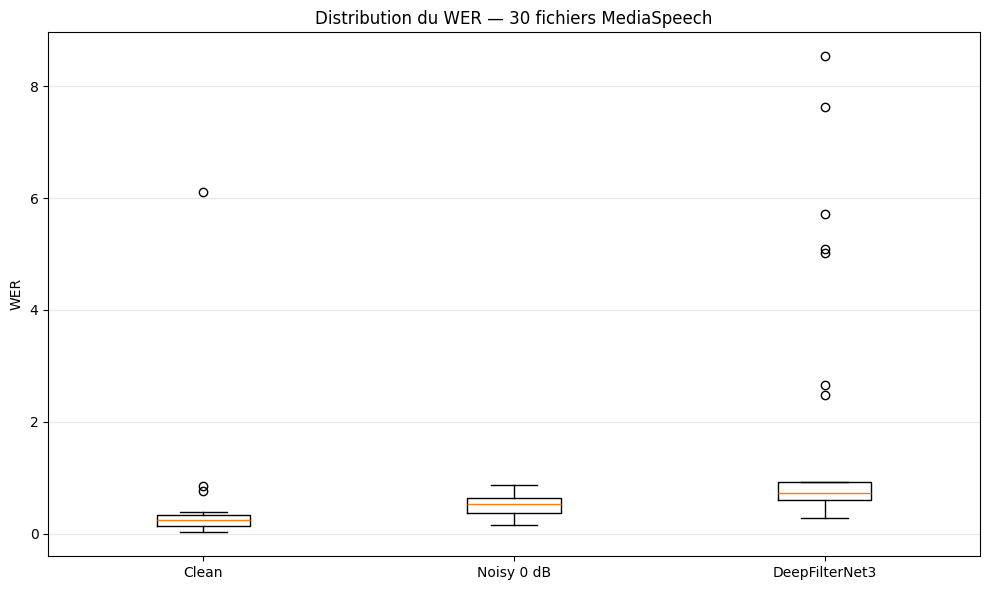

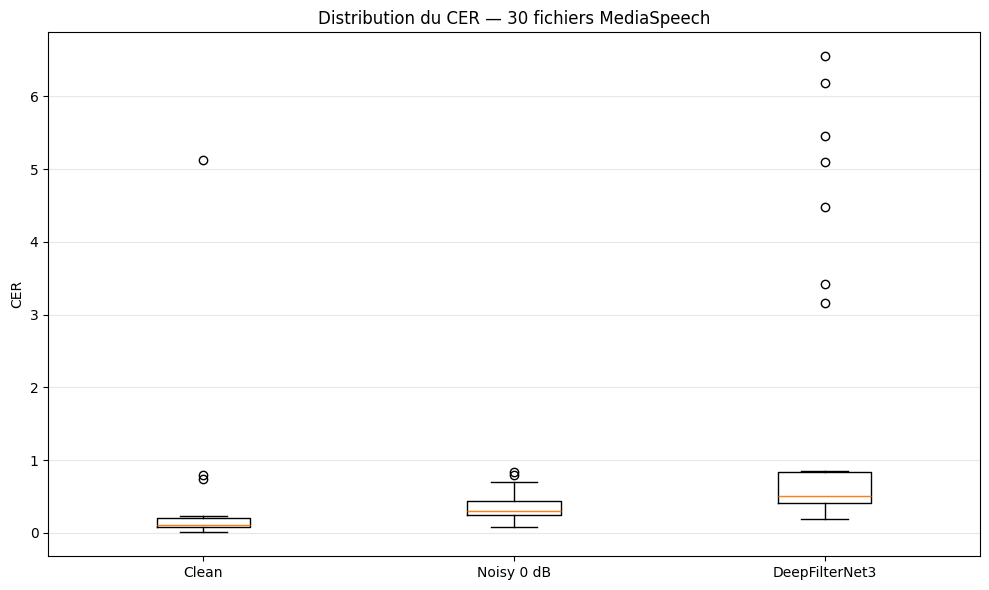

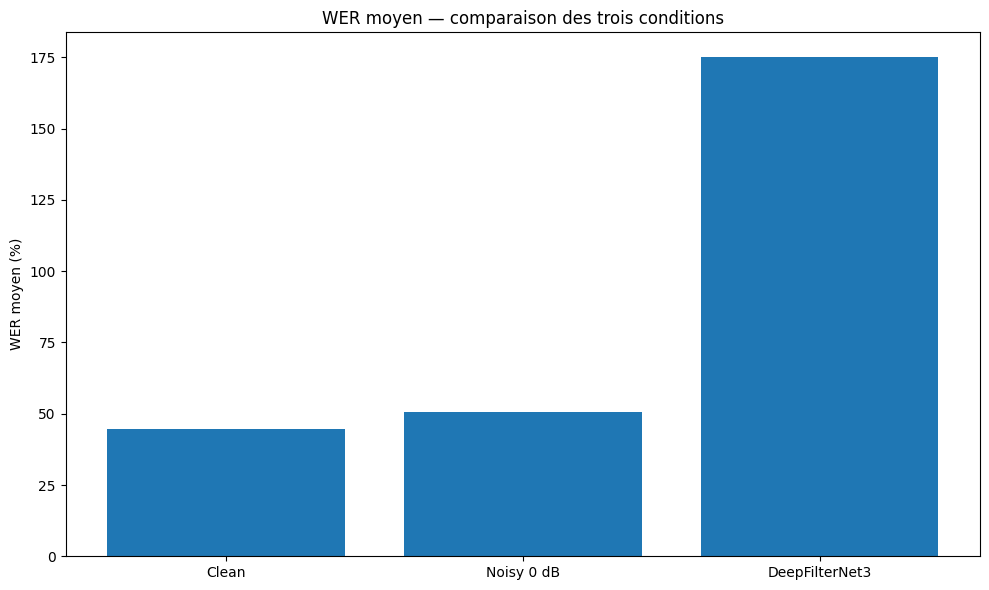


FICHIERS LES PLUS AMÉLIORÉS PAR DEEPFILTERNET3


,file,wer_noisy,wer_enhanced,relative_wer_gain_percent
5,508afcff-5d59-4cb3-ae17-ea998a272615.flac,0.641026,0.589744,8.000000
9,7504ede1-4c46-47e7-8b26-a3dea143284f.flac,0.526316,0.526316,0.000000
4,4d83cc4b-a3dd-4cba-b485-1e93f07d1a70.flac,0.666667,0.725490,-8.823529
25,d0dab676-fc66-4d2d-be32-a53b2022076f.flac,0.785714,0.857143,-9.090909
0,0038ee83-88a6-4bee-b81b-c4cb2d078fc2.flac,0.244444,0.288889,-18.181818
12,971748a4-8b50-4745-893a-6479404fec06.flac,0.423077,0.519231,-22.727273
8,56c76219-ca8b-4f25-bd23-b44e1b018192.flac,0.575758,0.727273,-26.315789
1,254ff50f-f9e3-4186-bca2-2c7bc99a4d6c.flac,0.473684,0.605263,-27.777778
20,b48587a1-9cc7-4fff-b2c0-5a483c92822a.flac,0.697674,0.930233,-33.333333
28,e993b34e-972a-4d79-a71c-16440a203c89.flac,0.533333,0.733333,-37.500000



FICHIERS LES PLUS DÉGRADÉS PAR DEEPFILTERNET3


,file,wer_noisy,wer_enhanced,relative_wer_gain_percent
15,a57328be-b0b8-4377-ba37-00f252168d51.flac,0.560976,8.536585,-1421.739130
24,d0275db2-ada0-44f9-92af-8a7f6c0c0d50.flac,0.868421,7.631579,-778.787879
26,d1aa0389-9f29-46f6-a947-c00774499e75.flac,0.604651,5.093023,-742.307692
7,5657cad5-4664-4f3d-a899-be9b45e03ec2.flac,0.710526,5.026316,-607.407407
22,c1ea8f0e-befe-4cd5-a5e6-0f75b73e924e.flac,0.820513,5.717949,-596.875000
17,a6628738-6490-4b8b-bdc7-5ef93e47713f.flac,0.555556,2.472222,-345.000000
3,3f251744-36bd-47a9-a98c-02e19cd60b71.flac,0.666667,2.666667,-300.000000
2,38a2d804-74c9-4d60-b2b3-54dc13bfd0ac.flac,0.156250,0.500000,-220.000000
11,9227d241-2a4b-48b4-bb40-019636b00ef3.flac,0.289474,0.763158,-163.636364
13,a1c4786b-259c-4f0b-a091-a1526bf80b23.flac,0.275000,0.725000,-163.636364



EXPÉRIENCE TERMINÉE
Résultats : /content/thesis_data/results_experiment_30

Fichiers principaux :
- /content/thesis_data/results_experiment_30/experiment_30_raw_results.csv
- /content/thesis_data/results_experiment_30/experiment_30_summary.csv
- /content/thesis_data/results_experiment_30/experiment_30_statistical_tests.csv
- /content/thesis_data/results_experiment_30/experiment_30_WER_boxplot.png
- /content/thesis_data/results_experiment_30/experiment_30_CER_boxplot.png
- /content/thesis_data/results_experiment_30/experiment_30_WER_means.png
- /content/thesis_data/results_experiment_30/experiment_30_final_report.txt

Aucun audio bruité n'a été sauvegardé.


In [63]:
# ============================================================
# EXPÉRIENCE 1 — 30 FICHIERS
# MediaSpeech FR
#
# Clean → Whisper
# Noisy 0 dB → Whisper
# Noisy 0 dB → DeepFilterNet3 → Whisper
#
# Aucun audio bruité n'est sauvegardé.
# ============================================================

import os
import re
import ctypes
import warnings
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import librosa
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import wilcoxon
from transformers import pipeline
from jiwer import wer, cer

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

BASE_DIR = Path("/content/thesis_data")

MEDIA_DIR = BASE_DIR / "mediaspeech_fr" / "FR"

RESULTS_DIR = BASE_DIR / "results_experiment_30"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_FILES = 30
SEED_SELECTION = 20260914
SEED_NOISE = 20260914

TARGET_SNR_DB = 0.0

ORIGINAL_SR = 16000
DF_SR = 48000

MODEL_NAME = "openai/whisper-small"

print("=" * 70)
print("EXPÉRIENCE 1 — 30 FICHIERS MEDIASPEECH")
print("=" * 70)

print(f"Corpus : {MEDIA_DIR}")
print(f"Nombre de fichiers : {N_FILES}")
print(f"SNR cible : {TARGET_SNR_DB} dB")
print(f"Seed sélection : {SEED_SELECTION}")
print(f"Seed bruit : {SEED_NOISE}")
print(f"GPU disponible : {torch.cuda.is_available()}")

# ------------------------------------------------------------
# 2. VÉRIFICATION DU CORPUS
# ------------------------------------------------------------

if not MEDIA_DIR.exists():
    raise FileNotFoundError(
        f"Dossier MediaSpeech introuvable : {MEDIA_DIR}"
    )

audio_files = sorted(MEDIA_DIR.glob("*.flac"))

if len(audio_files) == 0:
    raise RuntimeError("Aucun fichier FLAC trouvé.")

print(f"\nFichiers FLAC disponibles : {len(audio_files)}")

# ------------------------------------------------------------
# 3. CONSTRUCTION DES PAIRES AUDIO / TRANSCRIPTION
# ------------------------------------------------------------

pairs = []

for audio_path in audio_files:

    txt_path = audio_path.with_suffix(".txt")

    if not txt_path.exists():
        continue

    try:
        transcript = txt_path.read_text(
            encoding="utf-8",
            errors="ignore"
        ).strip()

        if transcript:
            pairs.append({
                "audio": str(audio_path),
                "reference": transcript
            })

    except Exception:
        pass

print(f"Paires audio/transcription valides : {len(pairs)}")

if len(pairs) < N_FILES:
    raise RuntimeError(
        f"Seulement {len(pairs)} paires disponibles. "
        f"Impossible d'en sélectionner {N_FILES}."
    )

# ------------------------------------------------------------
# 4. SÉLECTION REPRODUCTIBLE DES 30 FICHIERS
# ------------------------------------------------------------

rng_selection = np.random.default_rng(SEED_SELECTION)

selected_indices = rng_selection.choice(
    len(pairs),
    size=N_FILES,
    replace=False
)

selected_pairs = [pairs[i] for i in selected_indices]

selected_pairs = sorted(
    selected_pairs,
    key=lambda x: x["audio"]
)

print("\nFichiers sélectionnés :")

for i, item in enumerate(selected_pairs, 1):
    print(f"{i:02d}. {Path(item['audio']).name}")

# Sauvegarde de la sélection
selection_df = pd.DataFrame(selected_pairs)

selection_path = RESULTS_DIR / "selected_30_files.csv"

selection_df.to_csv(
    selection_path,
    index=False,
    encoding="utf-8"
)

print(f"\nSélection sauvegardée : {selection_path}")

# ------------------------------------------------------------
# 5. CHARGEMENT DE WHISPER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHARGEMENT DE WHISPER")
print("=" * 70)

device = 0 if torch.cuda.is_available() else -1

asr = pipeline(
    "automatic-speech-recognition",
    model=MODEL_NAME,
    device=device,
    torch_dtype=(
        torch.float16
        if device == 0
        else torch.float32
    )
)

print("Whisper chargé.")

# ------------------------------------------------------------
# 6. CHARGEMENT DE DEEPFILTERNET3
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHARGEMENT DE DEEPFILTERNET3")
print("=" * 70)

try:
    import deepfilternet_slim

    print("deepfilternet_slim disponible.")

except ImportError:
    raise RuntimeError(
        "deepfilternet_slim n'est pas installé.\n"
        "Exécute auparavant :\n"
        "pip install deepfilternet-slim"
    )

# Recherche automatique de la bibliothèque native
PACKAGE_DIR = Path(deepfilternet_slim.__file__).parent

LIB_PATH = PACKAGE_DIR / "_native" / "libdeepfilter.so"

if not LIB_PATH.exists():
    raise FileNotFoundError(
        f"Bibliothèque DeepFilterNet introuvable : {LIB_PATH}"
    )

print(f"Bibliothèque : {LIB_PATH}")

df_lib = ctypes.CDLL(str(LIB_PATH))

# ------------------------------------------------------------
# SIGNATURES C
# ------------------------------------------------------------

df_lib.df_create.argtypes = [
    ctypes.c_char_p,
    ctypes.c_float,
    ctypes.c_char_p
]

df_lib.df_create.restype = ctypes.c_void_p

df_lib.df_get_frame_length.argtypes = [
    ctypes.c_void_p
]

df_lib.df_get_frame_length.restype = ctypes.c_size_t

df_lib.df_process_frame.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.POINTER(ctypes.c_float)
]

df_lib.df_process_frame.restype = ctypes.c_float

df_lib.df_free.argtypes = [
    ctypes.c_void_p
]

df_lib.df_free.restype = None

# ------------------------------------------------------------
# 7. LOCALISATION DU MODÈLE
# ------------------------------------------------------------

MODEL_PATH = (
    PACKAGE_DIR
    / "_models"
    / "DeepFilterNet3_onnx.tar.gz"
)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modèle DeepFilterNet3 introuvable : {MODEL_PATH}"
    )

print(f"Modèle : {MODEL_PATH}")

# ------------------------------------------------------------
# 8. FONCTION DE NORMALISATION TEXTE
# ------------------------------------------------------------

def normalize_text(text):

    text = str(text).lower()

    # Apostrophes uniformisées
    text = text.replace("’", "'")

    # Suppression de caractères parasites
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ' ]+", " ", text)

    # Espaces multiples
    text = re.sub(r"\s+", " ", text)

    return text.strip()

# ------------------------------------------------------------
# 9. AJOUT DE BRUIT À SNR CONTRÔLÉ
# ------------------------------------------------------------

def add_white_noise_exact(signal, snr_db, rng):

    signal = signal.astype(np.float32)

    # Puissance RMS du signal
    signal_power = np.mean(signal ** 2)

    if signal_power <= 1e-12:
        raise ValueError("Signal quasiment silencieux.")

    # Puissance de bruit désirée
    noise_power = signal_power / (
        10 ** (snr_db / 10.0)
    )

    noise = rng.normal(
        0,
        np.sqrt(noise_power),
        size=signal.shape
    ).astype(np.float32)

    noisy = signal + noise

    measured_snr = 10 * np.log10(
        np.mean(signal ** 2) /
        np.mean(noise ** 2)
    )

    return noisy.astype(np.float32), measured_snr

# ------------------------------------------------------------
# 10. DEEPFILTERNET3
# ------------------------------------------------------------

def enhance_with_deepfilternet3(
    audio_16k,
    sr=16000
):

    # --------------------------------------------------------
    # Resampling 16 kHz → 48 kHz
    # --------------------------------------------------------

    if sr != DF_SR:

        audio_48k = librosa.resample(
            audio_16k.astype(np.float32),
            orig_sr=sr,
            target_sr=DF_SR
        ).astype(np.float32)

    else:
        audio_48k = audio_16k.astype(np.float32)

    # --------------------------------------------------------
    # Création d'une nouvelle instance pour CHAQUE audio
    # --------------------------------------------------------

    state = df_lib.df_create(
        str(MODEL_PATH).encode("utf-8"),
        ctypes.c_float(100.0),
        b"error"
    )

    if not state:
        raise RuntimeError(
            "Impossible de créer l'état DeepFilterNet3."
        )

    try:

        frame_len = df_lib.df_get_frame_length(state)

        # Padding pour avoir des frames complètes
        n_frames = int(
            np.ceil(len(audio_48k) / frame_len)
        )

        padded_len = n_frames * frame_len

        padded = np.zeros(
            padded_len,
            dtype=np.float32
        )

        padded[:len(audio_48k)] = audio_48k

        output = np.zeros_like(padded)

        for i in range(n_frames):

            start = i * frame_len
            end = start + frame_len

            input_frame = np.ascontiguousarray(
                padded[start:end],
                dtype=np.float32
            )

            output_frame = np.zeros(
                frame_len,
                dtype=np.float32
            )

            in_ptr = input_frame.ctypes.data_as(
                ctypes.POINTER(ctypes.c_float)
            )

            out_ptr = output_frame.ctypes.data_as(
                ctypes.POINTER(ctypes.c_float)
            )

            df_lib.df_process_frame(
                state,
                in_ptr,
                out_ptr
            )

            output[start:end] = output_frame

        output = output[:len(audio_48k)]

    finally:

        df_lib.df_free(state)

    # --------------------------------------------------------
    # Resampling 48 kHz → 16 kHz
    # --------------------------------------------------------

    if sr != DF_SR:

        enhanced_16k = librosa.resample(
            output,
            orig_sr=DF_SR,
            target_sr=sr
        ).astype(np.float32)

    else:
        enhanced_16k = output

    return enhanced_16k

# ------------------------------------------------------------
# 11. FONCTION WHISPER
# ------------------------------------------------------------

def transcribe(audio):

    result = asr(
        audio,
        generate_kwargs={
            "language": "french",
            "task": "transcribe"
        }
    )

    return result["text"].strip()

# ------------------------------------------------------------
# 12. FONCTION DE CALCUL WER / CER
# ------------------------------------------------------------

def compute_metrics(reference, prediction):

    ref = normalize_text(reference)
    hyp = normalize_text(prediction)

    return (
        wer(ref, hyp),
        cer(ref, hyp)
    )

# ------------------------------------------------------------
# 13. RNG DU BRUIT
# ------------------------------------------------------------

rng_noise = np.random.default_rng(SEED_NOISE)

# ------------------------------------------------------------
# 14. EXPÉRIMENTATION
# ------------------------------------------------------------

results = []

print("\n" + "=" * 70)
print("DÉBUT DE L'EXPÉRIENCE")
print("=" * 70)

for idx, item in enumerate(selected_pairs, 1):

    audio_path = item["audio"]
    reference = item["reference"]

    filename = Path(audio_path).name

    print("\n" + "-" * 70)
    print(f"[{idx}/{N_FILES}] {filename}")
    print("-" * 70)

    try:

        # ----------------------------------------------------
        # CHARGEMENT
        # ----------------------------------------------------

        audio, sr = sf.read(
            audio_path,
            dtype="float32"
        )

        # Si stéréo → mono
        if audio.ndim > 1:
            audio = np.mean(
                audio,
                axis=1
            ).astype(np.float32)

        if sr != ORIGINAL_SR:

            audio = librosa.resample(
                audio,
                orig_sr=sr,
                target_sr=ORIGINAL_SR
            ).astype(np.float32)

            sr = ORIGINAL_SR

        # ----------------------------------------------------
        # CONDITION 1 — CLEAN
        # ----------------------------------------------------

        prediction_clean = transcribe(audio)

        wer_clean, cer_clean = compute_metrics(
            reference,
            prediction_clean
        )

        print(
            f"CLEAN      WER={wer_clean:.4f} "
            f"CER={cer_clean:.4f}"
        )

        # ----------------------------------------------------
        # CONDITION 2 — NOISY 0 dB
        # ----------------------------------------------------

        noisy, measured_snr = add_white_noise_exact(
            audio,
            TARGET_SNR_DB,
            rng_noise
        )

        prediction_noisy = transcribe(noisy)

        wer_noisy, cer_noisy = compute_metrics(
            reference,
            prediction_noisy
        )

        print(
            f"NOISY      WER={wer_noisy:.4f} "
            f"CER={cer_noisy:.4f} "
            f"SNR={measured_snr:.4f} dB"
        )

        # ----------------------------------------------------
        # CONDITION 3 — DEEPFILTERNET3 + WHISPER
        # ----------------------------------------------------

        enhanced = enhance_with_deepfilternet3(
            noisy,
            sr=ORIGINAL_SR
        )

        prediction_enhanced = transcribe(
            enhanced
        )

        wer_enhanced, cer_enhanced = compute_metrics(
            reference,
            prediction_enhanced
        )

        print(
            f"DFN3       WER={wer_enhanced:.4f} "
            f"CER={cer_enhanced:.4f}"
        )

        # ----------------------------------------------------
        # VARIATIONS
        # ----------------------------------------------------

        delta_wer_noise = (
            wer_noisy - wer_clean
        )

        delta_wer_enhancement = (
            wer_enhanced - wer_noisy
        )

        delta_cer_noise = (
            cer_noisy - cer_clean
        )

        delta_cer_enhancement = (
            cer_enhanced - cer_noisy
        )

        # ----------------------------------------------------
        # AMÉLIORATION RELATIVE
        # ----------------------------------------------------

        if wer_noisy > 0:
            relative_wer_gain = (
                (wer_noisy - wer_enhanced)
                / wer_noisy
            ) * 100
        else:
            relative_wer_gain = np.nan

        if cer_noisy > 0:
            relative_cer_gain = (
                (cer_noisy - cer_enhanced)
                / cer_noisy
            ) * 100
        else:
            relative_cer_gain = np.nan

        # ----------------------------------------------------
        # AMÉLIORATION INDIVIDUELLE
        # ----------------------------------------------------

        dfn_improves_wer = (
            wer_enhanced < wer_noisy
        )

        dfn_improves_cer = (
            cer_enhanced < cer_noisy
        )

        results.append({

            "file": filename,

            "reference": reference,

            "prediction_clean": prediction_clean,

            "prediction_noisy": prediction_noisy,

            "prediction_enhanced": prediction_enhanced,

            "measured_snr_db": measured_snr,

            "wer_clean": wer_clean,
            "cer_clean": cer_clean,

            "wer_noisy": wer_noisy,
            "cer_noisy": cer_noisy,

            "wer_enhanced": wer_enhanced,
            "cer_enhanced": cer_enhanced,

            "delta_wer_noise": delta_wer_noise,

            "delta_wer_enhancement":
                delta_wer_enhancement,

            "delta_cer_noise": delta_cer_noise,

            "delta_cer_enhancement":
                delta_cer_enhancement,

            "relative_wer_gain_percent":
                relative_wer_gain,

            "relative_cer_gain_percent":
                relative_cer_gain,

            "dfn_improves_wer":
                dfn_improves_wer,

            "dfn_improves_cer":
                dfn_improves_cer
        })

    except Exception as e:

        print(
            f"ERREUR sur {filename} : {repr(e)}"
        )

# ------------------------------------------------------------
# 15. DATAFRAME FINAL
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

if len(results_df) == 0:
    raise RuntimeError(
        "Aucun résultat exploitable."
    )

raw_path = RESULTS_DIR / "experiment_30_raw_results.csv"

results_df.to_csv(
    raw_path,
    index=False,
    encoding="utf-8"
)

print(
    f"\nRésultats bruts sauvegardés : {raw_path}"
)

# ------------------------------------------------------------
# 16. STATISTIQUES DESCRIPTIVES
# ------------------------------------------------------------

conditions = {

    "Clean": (
        "wer_clean",
        "cer_clean"
    ),

    "Noisy 0 dB": (
        "wer_noisy",
        "cer_noisy"
    ),

    "DeepFilterNet3 + Whisper": (
        "wer_enhanced",
        "cer_enhanced"
    )
}

summary_rows = []

for condition, (wer_col, cer_col) in conditions.items():

    summary_rows.append({

        "condition": condition,

        "n": len(results_df),

        "WER_mean":
            results_df[wer_col].mean(),

        "WER_median":
            results_df[wer_col].median(),

        "WER_std":
            results_df[wer_col].std(),

        "WER_min":
            results_df[wer_col].min(),

        "WER_max":
            results_df[wer_col].max(),

        "CER_mean":
            results_df[cer_col].mean(),

        "CER_median":
            results_df[cer_col].median(),

        "CER_std":
            results_df[cer_col].std(),

        "CER_min":
            results_df[cer_col].min(),

        "CER_max":
            results_df[cer_col].max()
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = RESULTS_DIR / "experiment_30_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 17. AFFICHAGE DES STATISTIQUES
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 90)

display(
    summary_df.style.format({
        "WER_mean": "{:.4f}",
        "WER_median": "{:.4f}",
        "WER_std": "{:.4f}",
        "WER_min": "{:.4f}",
        "WER_max": "{:.4f}",
        "CER_mean": "{:.4f}",
        "CER_median": "{:.4f}",
        "CER_std": "{:.4f}",
        "CER_min": "{:.4f}",
        "CER_max": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 18. POURCENTAGES
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("RÉSULTATS EN POURCENTAGE")
print("=" * 90)

for _, row in summary_df.iterrows():

    print(
        f"{row['condition']:30s} | "
        f"WER moyenne = {row['WER_mean']*100:6.2f}% | "
        f"WER médiane = {row['WER_median']*100:6.2f}% | "
        f"CER moyenne = {row['CER_mean']*100:6.2f}%"
    )

# ------------------------------------------------------------
# 19. GAIN / DÉGRADATION GLOBAL
# ------------------------------------------------------------

mean_wer_noisy = results_df["wer_noisy"].mean()
mean_wer_enhanced = results_df["wer_enhanced"].mean()

mean_cer_noisy = results_df["cer_noisy"].mean()
mean_cer_enhanced = results_df["cer_enhanced"].mean()

relative_wer = (
    (mean_wer_noisy - mean_wer_enhanced)
    / mean_wer_noisy
) * 100

relative_cer = (
    (mean_cer_noisy - mean_cer_enhanced)
    / mean_cer_noisy
) * 100

print("\n" + "=" * 90)
print("IMPACT GLOBAL DE DEEPFILTERNET3")
print("=" * 90)

print(
    f"WER bruité       : {mean_wer_noisy*100:.2f}%"
)

print(
    f"WER DFN3          : {mean_wer_enhanced*100:.2f}%"
)

print(
    f"Variation WER     : {relative_wer:+.2f}%"
)

print()

print(
    f"CER bruité       : {mean_cer_noisy*100:.2f}%"
)

print(
    f"CER DFN3          : {mean_cer_enhanced*100:.2f}%"
)

print(
    f"Variation CER     : {relative_cer:+.2f}%"
)

# ------------------------------------------------------------
# 20. NOMBRE DE FICHIERS AMÉLIORÉS
# ------------------------------------------------------------

n_improve_wer = results_df["dfn_improves_wer"].sum()
n_improve_cer = results_df["dfn_improves_cer"].sum()

n_total = len(results_df)

print("\n" + "=" * 90)
print("ANALYSE PAR FICHIER")
print("=" * 90)

print(
    f"DFN3 améliore le WER : "
    f"{n_improve_wer}/{n_total} "
    f"({n_improve_wer/n_total*100:.2f}%)"
)

print(
    f"DFN3 améliore le CER : "
    f"{n_improve_cer}/{n_total} "
    f"({n_improve_cer/n_total*100:.2f}%)"
)

print(
    f"DFN3 dégrade le WER : "
    f"{n_total-n_improve_wer}/{n_total}"
)

print(
    f"DFN3 dégrade le CER : "
    f"{n_total-n_improve_cer}/{n_total}"
)

# ------------------------------------------------------------
# 21. TEST DE WILCOXON — WER
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TEST STATISTIQUE — WILCOXON")
print("=" * 90)

try:

    stat_wer, p_wer = wilcoxon(
        results_df["wer_noisy"],
        results_df["wer_enhanced"],
        alternative="two-sided"
    )

    print(
        f"WER : statistique = {stat_wer:.4f}, "
        f"p = {p_wer:.6f}"
    )

except Exception as e:

    stat_wer = np.nan
    p_wer = np.nan

    print(
        f"Test WER impossible : {e}"
    )

# ------------------------------------------------------------
# 22. TEST DE WILCOXON — CER
# ------------------------------------------------------------

try:

    stat_cer, p_cer = wilcoxon(
        results_df["cer_noisy"],
        results_df["cer_enhanced"],
        alternative="two-sided"
    )

    print(
        f"CER : statistique = {stat_cer:.4f}, "
        f"p = {p_cer:.6f}"
    )

except Exception as e:

    stat_cer = np.nan
    p_cer = np.nan

    print(
        f"Test CER impossible : {e}"
    )

# ------------------------------------------------------------
# 23. INTERPRÉTATION STATISTIQUE
# ------------------------------------------------------------

print("\nInterprétation provisoire :")

if not np.isnan(p_wer):

    if p_wer < 0.05:
        print(
            "WER : différence statistiquement significative "
            "(seuil α = 0,05)."
        )
    else:
        print(
            "WER : différence non statistiquement significative "
            "(seuil α = 0,05)."
        )

if not np.isnan(p_cer):

    if p_cer < 0.05:
        print(
            "CER : différence statistiquement significative "
            "(seuil α = 0,05)."
        )
    else:
        print(
            "CER : différence non statistiquement significative "
            "(seuil α = 0,05)."
        )

# ------------------------------------------------------------
# 24. SAUVEGARDE DES TESTS STATISTIQUES
# ------------------------------------------------------------

stats_df = pd.DataFrame([{

    "n": n_total,

    "WER_noisy_mean":
        mean_wer_noisy,

    "WER_enhanced_mean":
        mean_wer_enhanced,

    "WER_relative_change_percent":
        relative_wer,

    "CER_noisy_mean":
        mean_cer_noisy,

    "CER_enhanced_mean":
        mean_cer_enhanced,

    "CER_relative_change_percent":
        relative_cer,

    "wilcoxon_WER_stat":
        stat_wer,

    "wilcoxon_WER_p":
        p_wer,

    "wilcoxon_CER_stat":
        stat_cer,

    "wilcoxon_CER_p":
        p_cer,

    "files_WER_improved":
        n_improve_wer,

    "files_CER_improved":
        n_improve_cer
}])

stats_path = RESULTS_DIR / "experiment_30_statistical_tests.csv"

stats_df.to_csv(
    stats_path,
    index=False,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 25. GRAPHIQUE — WER
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        results_df["wer_clean"],
        results_df["wer_noisy"],
        results_df["wer_enhanced"]
    ],
    labels=[
        "Clean",
        "Noisy 0 dB",
        "DeepFilterNet3"
    ]
)

plt.ylabel("WER")
plt.title(
    "Distribution du WER — 30 fichiers MediaSpeech"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

wer_plot = RESULTS_DIR / "experiment_30_WER_boxplot.png"

plt.savefig(
    wer_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 26. GRAPHIQUE — CER
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        results_df["cer_clean"],
        results_df["cer_noisy"],
        results_df["cer_enhanced"]
    ],
    labels=[
        "Clean",
        "Noisy 0 dB",
        "DeepFilterNet3"
    ]
)

plt.ylabel("CER")
plt.title(
    "Distribution du CER — 30 fichiers MediaSpeech"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

cer_plot = RESULTS_DIR / "experiment_30_CER_boxplot.png"

plt.savefig(
    cer_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 27. GRAPHIQUE — COMPARAISON DES MOYENNES
# ------------------------------------------------------------

mean_values_wer = [
    results_df["wer_clean"].mean(),
    results_df["wer_noisy"].mean(),
    results_df["wer_enhanced"].mean()
]

plt.figure(figsize=(10, 6))

plt.bar(
    [
        "Clean",
        "Noisy 0 dB",
        "DeepFilterNet3"
    ],
    np.array(mean_values_wer) * 100
)

plt.ylabel("WER moyen (%)")

plt.title(
    "WER moyen — comparaison des trois conditions"
)

plt.tight_layout()

mean_plot = RESULTS_DIR / "experiment_30_WER_means.png"

plt.savefig(
    mean_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 28. TOP DES FICHIERS LES PLUS AMÉLIORÉS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FICHIERS LES PLUS AMÉLIORÉS PAR DEEPFILTERNET3")
print("=" * 90)

improved = results_df.sort_values(
    "relative_wer_gain_percent",
    ascending=False
)

display(
    improved[
        [
            "file",
            "wer_noisy",
            "wer_enhanced",
            "relative_wer_gain_percent"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# 29. TOP DES FICHIERS LES PLUS DÉGRADÉS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FICHIERS LES PLUS DÉGRADÉS PAR DEEPFILTERNET3")
print("=" * 90)

degraded = results_df.sort_values(
    "relative_wer_gain_percent",
    ascending=True
)

display(
    degraded[
        [
            "file",
            "wer_noisy",
            "wer_enhanced",
            "relative_wer_gain_percent"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# 30. RAPPORT FINAL
# ------------------------------------------------------------

report_path = RESULTS_DIR / "experiment_30_final_report.txt"

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "EXPERIENCE 1 — MEDIASPEECH / DEEPFILTERNET3\n"
    )

    f.write("=" * 60 + "\n\n")

    f.write(
        f"Nombre de fichiers : {n_total}\n"
    )

    f.write(
        f"SNR cible : {TARGET_SNR_DB} dB\n"
    )

    f.write(
        f"Seed sélection : {SEED_SELECTION}\n"
    )

    f.write(
        f"Seed bruit : {SEED_NOISE}\n\n"
    )

    f.write(
        f"WER Clean : "
        f"{results_df['wer_clean'].mean()*100:.2f}%\n"
    )

    f.write(
        f"WER Noisy : "
        f"{results_df['wer_noisy'].mean()*100:.2f}%\n"
    )

    f.write(
        f"WER DeepFilterNet3 : "
        f"{results_df['wer_enhanced'].mean()*100:.2f}%\n\n"
    )

    f.write(
        f"CER Clean : "
        f"{results_df['cer_clean'].mean()*100:.2f}%\n"
    )

    f.write(
        f"CER Noisy : "
        f"{results_df['cer_noisy'].mean()*100:.2f}%\n"
    )

    f.write(
        f"CER DeepFilterNet3 : "
        f"{results_df['cer_enhanced'].mean()*100:.2f}%\n\n"
    )

    f.write(
        f"Variation relative WER : "
        f"{relative_wer:+.2f}%\n"
    )

    f.write(
        f"Variation relative CER : "
        f"{relative_cer:+.2f}%\n\n"
    )

    f.write(
        f"Fichiers avec amélioration WER : "
        f"{n_improve_wer}/{n_total}\n"
    )

    f.write(
        f"Fichiers avec amélioration CER : "
        f"{n_improve_cer}/{n_total}\n\n"
    )

    f.write(
        f"Wilcoxon WER p-value : "
        f"{p_wer}\n"
    )

    f.write(
        f"Wilcoxon CER p-value : "
        f"{p_cer}\n"
    )

print("\n" + "=" * 90)
print("EXPÉRIENCE TERMINÉE")
print("=" * 90)

print(f"Résultats : {RESULTS_DIR}")
print()
print("Fichiers principaux :")
print(f"- {raw_path}")
print(f"- {summary_path}")
print(f"- {stats_path}")
print(f"- {wer_plot}")
print(f"- {cer_plot}")
print(f"- {mean_plot}")
print(f"- {report_path}")

print("\nAucun audio bruité n'a été sauvegardé.")

AUDIT DES SORTIES DEEPFILTERNET3

--------------------------------------------------------------------------------
a57328be-b0b8-4377-ba37-00f252168d51.flac
--------------------------------------------------------------------------------

CLEAN
{'samples': 235200, 'duration_s': 14.7, 'rms': np.float32(0.15667596), 'rms_db': np.float32(-16.099953), 'peak': np.float32(0.879303), 'peak_db': np.float32(-1.1172291), 'min': np.float32(-0.8548889), 'max': np.float32(0.879303)}

NOISY
{'samples': 235200, 'duration_s': 14.7, 'rms': np.float32(0.2216376), 'rms_db': np.float32(-13.0871315), 'peak': np.float32(1.2340372), 'peak_db': np.float32(1.8265648), 'min': np.float32(-1.2340372), 'max': np.float32(1.0808055)}

DEEPFILTERNET3
{'samples': 235200, 'duration_s': 14.7, 'rms': np.float32(0.14192685), 'rms_db': np.float32(-16.95871), 'peak': np.float32(0.75186497), 'peak_db': np.float32(-2.477203), 'min': np.float32(-0.75186497), 'max': np.float32(0.6400586)}

SNR bruit mesuré : 0.012163 dB

Durées

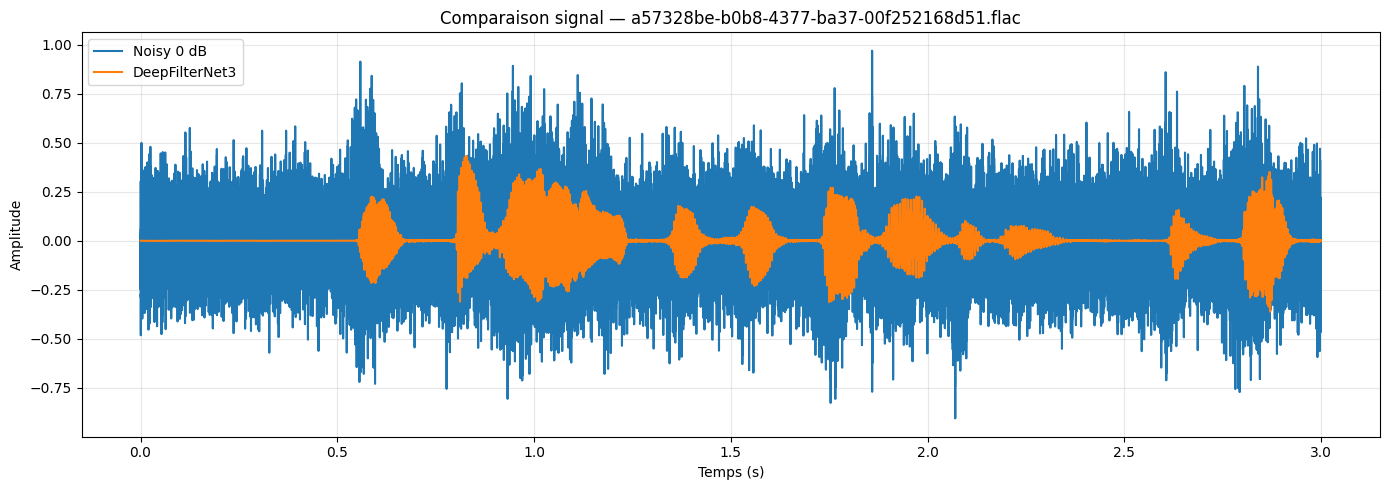


--------------------------------------------------------------------------------
d0275db2-ada0-44f9-92af-8a7f6c0c0d50.flac
--------------------------------------------------------------------------------


In [ ]:
# ============================================================
# AUDIT SIGNAL DEEPFILTERNET3
# ============================================================

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Fichiers problématiques identifiés
# ------------------------------------------------------------

test_files = [
    "a57328be-b0b8-4377-ba37-00f252168d51.flac",
    "d0275db2-ada0-44f9-92af-8a7f6c0c0d50.flac",
    "5657cad5-4664-4f3d-a899-be9b45e03ec2.flac"
]

def signal_stats(x):

    x = np.asarray(x, dtype=np.float32)

    rms = np.sqrt(np.mean(x ** 2))

    peak = np.max(np.abs(x))

    rms_db = 20 * np.log10(
        max(rms, 1e-12)
    )

    peak_db = 20 * np.log10(
        max(peak, 1e-12)
    )

    return {
        "samples": len(x),
        "duration_s": len(x) / ORIGINAL_SR,
        "rms": rms,
        "rms_db": rms_db,
        "peak": peak,
        "peak_db": peak_db,
        "min": np.min(x),
        "max": np.max(x)
    }

print("=" * 80)
print("AUDIT DES SORTIES DEEPFILTERNET3")
print("=" * 80)

for filename in test_files:

    print("\n" + "-" * 80)
    print(filename)
    print("-" * 80)

    audio_path = MEDIA_DIR / filename

    # --------------------------------------------------------
    # Lecture
    # --------------------------------------------------------

    clean, sr = sf.read(
        audio_path,
        dtype="float32"
    )

    if clean.ndim > 1:
        clean = np.mean(
            clean,
            axis=1
        ).astype(np.float32)

    if sr != ORIGINAL_SR:

        clean = librosa.resample(
            clean,
            orig_sr=sr,
            target_sr=ORIGINAL_SR
        ).astype(np.float32)

    # --------------------------------------------------------
    # Bruit 0 dB
    # --------------------------------------------------------

    # Seed indépendant pour reproductibilité
    local_rng = np.random.default_rng(
        20260914
    )

    noisy, measured_snr = add_white_noise_exact(
        clean,
        0.0,
        local_rng
    )

    # --------------------------------------------------------
    # DeepFilterNet3
    # --------------------------------------------------------

    enhanced = enhance_with_deepfilternet3(
        noisy,
        sr=ORIGINAL_SR
    )

    # --------------------------------------------------------
    # Statistiques
    # --------------------------------------------------------

    stats_clean = signal_stats(clean)
    stats_noisy = signal_stats(noisy)
    stats_enhanced = signal_stats(enhanced)

    print("\nCLEAN")
    print(stats_clean)

    print("\nNOISY")
    print(stats_noisy)

    print("\nDEEPFILTERNET3")
    print(stats_enhanced)

    print(
        f"\nSNR bruit mesuré : "
        f"{measured_snr:.6f} dB"
    )

    # --------------------------------------------------------
    # Durées
    # --------------------------------------------------------

    print("\nDurées :")

    print(
        f"Clean     : "
        f"{len(clean)/ORIGINAL_SR:.4f} s"
    )

    print(
        f"Noisy     : "
        f"{len(noisy)/ORIGINAL_SR:.4f} s"
    )

    print(
        f"Enhanced  : "
        f"{len(enhanced)/ORIGINAL_SR:.4f} s"
    )

    # --------------------------------------------------------
    # Corrélation
    # --------------------------------------------------------

    n = min(
        len(noisy),
        len(enhanced)
    )

    noisy_cmp = noisy[:n]
    enhanced_cmp = enhanced[:n]

    correlation = np.corrcoef(
        noisy_cmp,
        enhanced_cmp
    )[0, 1]

    print(
        f"\nCorrélation noisy/enhanced : "
        f"{correlation:.6f}"
    )

    # --------------------------------------------------------
    # Décalage par corrélation
    # --------------------------------------------------------

    max_lag = min(
        5000,
        n // 10
    )

    noisy_center = noisy_cmp[
        max_lag:-max_lag
    ]

    enhanced_center = enhanced_cmp[
        max_lag:-max_lag
    ]

    best_lag = 0
    best_corr = -1

    for lag in range(
        -max_lag,
        max_lag + 1,
        100
    ):

        if lag < 0:

            a = noisy_center[-lag:]
            b = enhanced_center[:len(a)]

        elif lag > 0:

            a = noisy_center[:-lag]
            b = enhanced_center[lag:lag+len(a)]

        else:

            a = noisy_center
            b = enhanced_center

        if len(a) < 1000:
            continue

        c = np.corrcoef(a, b)[0, 1]

        if np.isfinite(c) and c > best_corr:

            best_corr = c
            best_lag = lag

    print(
        f"Décalage approximatif détecté : "
        f"{best_lag} samples"
    )

    print(
        f"Décalage temporel approximatif : "
        f"{best_lag/ORIGINAL_SR*1000:.2f} ms"
    )

    print(
        f"Corrélation maximale approximative : "
        f"{best_corr:.6f}"
    )

    # --------------------------------------------------------
    # Visualisation
    # --------------------------------------------------------

    duration = min(
        3.0,
        len(clean) / ORIGINAL_SR
    )

    n_plot = int(
        duration * ORIGINAL_SR
    )

    t = np.arange(n_plot) / ORIGINAL_SR

    plt.figure(figsize=(14, 5))

    plt.plot(
        t,
        noisy[:n_plot],
        label="Noisy 0 dB"
    )

    plt.plot(
        t,
        enhanced[:n_plot],
        label="DeepFilterNet3"
    )

    plt.xlabel("Temps (s)")
    plt.ylabel("Amplitude")

    plt.title(
        f"Comparaison signal — {filename}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

print("\n" + "=" * 80)
print("AUDIT TERMINÉ")
print("=" * 80)